## Install Libraries

In [138]:
# ====================
# 1. INSTALL LIBRARIES
# ====================

!pip -q install pandas numpy matplotlib seaborn plotly scikit-learn scipy statsmodels catboost shap joblib streamlit duckdb

# Optional: only needed for Parquet files
!pip -q install pyarrow

In [139]:
# ===================
# 2. IMPORT LIBRARIES
# ===================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import mannwhitneyu, wilcoxon
import statsmodels.formula.api as smf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from catboost import CatBoostRegressor, Pool

import shap
import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Setup complete")

Setup complete


In [140]:
# ========================
# 3. PROJECT CONFIGURATION
# ========================

PROJECT_DIR = Path.cwd()

CSV_PATH = PROJECT_DIR / "apple_products_pricing_2020_2026.csv"

OUTPUT_DIR = PROJECT_DIR / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

CLEANED_CSV_PATH = OUTPUT_DIR / "cleaned_apple_prices.csv"
DAILY_CSV_PATH = OUTPUT_DIR / "daily_market_prices.csv"
QUALITY_REPORT_PATH = OUTPUT_DIR / "data_quality_report.json"

print("Project directory:", PROJECT_DIR)
print("Dataset path:", CSV_PATH)
print("Output directory:", OUTPUT_DIR)

Project directory: c:\Users\dbui\Downloads\apple_pricing_project
Dataset path: c:\Users\dbui\Downloads\apple_pricing_project\apple_products_pricing_2020_2026.csv
Output directory: c:\Users\dbui\Downloads\apple_pricing_project\outputs


In [141]:
# ===============
# 4. LOAD DATASET
# ===============

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at:\n{CSV_PATH}\n\n"
        "Move the CSV file into your project folder or update CSV_PATH."
    )

raw_df = pd.read_csv(CSV_PATH)

print("Dataset loaded successfully")
print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])

display(raw_df.head())

Dataset loaded successfully
Rows: 80000
Columns: 14


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,"43,322.41",-1.60,NaN,In Stock,4.70,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,"42,320.43",-1.70,NaN,Out of Stock,4.60,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,"40,879.36",1.50,NaN,In Stock,4.40,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,"42,008.70",0.90,NaN,In Stock,4.80,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,"41,984.28",-1.70,NaN,In Stock,4.70,35


In [142]:
# =====================
# 5. INITIAL DATA AUDIT
# =====================

print("Dataset shape:")
print(raw_df.shape)

print("\nColumn names:")
print(raw_df.columns.tolist())

print("\nData types:")
display(raw_df.dtypes.to_frame("data_type"))

print("\nMissing values:")
missing_summary = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_percentage": raw_df.isna().mean() * 100,
})

display(
    missing_summary.sort_values(
        "missing_count",
        ascending=False,
    )
)

print("\nExact duplicate rows:")
print(raw_df.duplicated().sum())

print("\nBasic statistical summary:")
display(raw_df.describe(include="all").T)

Dataset shape:
(80000, 14)

Column names:
['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Launch_Price_INR', 'Current_Price_USD', 'Current_Price_INR', 'Discount_Pct', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count']

Data types:


,data_type
Date,str
Platform,str
Product_Category,str
Model_Name,str
Condition,str
Launch_Price_USD,int64
Launch_Price_INR,int64
Current_Price_USD,float64
Current_Price_INR,float64
Discount_Pct,float64



Missing values:


,missing_count,missing_percentage
Sale_Event,73351,91.69
Date,0,0.00
Product_Category,0,0.00
Model_Name,0,0.00
Condition,0,0.00
Platform,0,0.00
Launch_Price_USD,0,0.00
Launch_Price_INR,0,0.00
Current_Price_INR,0,0.00
Current_Price_USD,0,0.00



Exact duplicate rows:
0

Basic statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,80000,2130,2025-06-11,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,80000,2,Flipkart,40043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,80000,4,iPhone,28589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model_Name,80000,31,iPhone 14 Pro 128GB,2734,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Condition,80000,2,New,59985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Launch_Price_USD,"80,000.00",NaN,NaN,NaN,963.96,470.09,329.00,599.00,799.00,"1,199.00","1,999.00"
Launch_Price_INR,"80,000.00",NaN,NaN,NaN,"94,467.99","46,068.47","32,242.00","58,702.00","78,302.00","117,502.00","195,902.00"
Current_Price_USD,"80,000.00",NaN,NaN,NaN,782.77,461.67,109.93,432.93,699.74,989.11,"2,038.97"
Current_Price_INR,"80,000.00",NaN,NaN,NaN,"74,628.34","45,117.87","9,157.68","41,686.83","67,324.02","96,568.12","203,668.71"
Discount_Pct,"80,000.00",NaN,NaN,NaN,21.42,16.70,-2.00,6.70,21.30,36.80,73.10


In [143]:
# ===========================
# 6. STANDARDIZE COLUMN NAMES
# ===========================

df = raw_df.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['date', 'platform', 'product_category', 'model_name', 'condition', 'launch_price_usd', 'launch_price_inr', 'current_price_usd', 'current_price_inr', 'discount_pct', 'sale_event', 'stock_status', 'rating', 'reviews_count']


In [144]:
# ==========================
# 7. VERIFY REQUIRED COLUMNS
# ==========================

required_columns = [
    "date",
    "platform",
    "product_category",
    "model_name",
    "condition",
    "launch_price_usd",
    "current_price_usd",
    "discount_pct",
    "sale_event",
    "stock_status",
    "rating",
    "reviews_count",
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_required_columns:
    raise ValueError(
        f"Required columns are missing: {missing_required_columns}"
    )

print("All required columns are available")

All required columns are available


In [145]:
# ===================
# 8. DROP INR COLUMNS
# ===================

inr_columns = [
    column
    for column in [
        "launch_price_inr",
        "current_price_inr",
    ]
    if column in df.columns
]

df = df.drop(columns=inr_columns)

print("Dropped INR columns:", inr_columns)
print("Remaining columns:", df.columns.tolist())

Dropped INR columns: ['launch_price_inr', 'current_price_inr']
Remaining columns: ['date', 'platform', 'product_category', 'model_name', 'condition', 'launch_price_usd', 'current_price_usd', 'discount_pct', 'sale_event', 'stock_status', 'rating', 'reviews_count']


In [146]:
# =====================
# 9. CORRECT DATA TYPES
# =====================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce",
)

numeric_columns = [
    "launch_price_usd",
    "current_price_usd",
    "discount_pct",
    "rating",
    "reviews_count",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )

categorical_columns = [
    "platform",
    "product_category",
    "model_name",
    "condition",
    "sale_event",
    "stock_status",
]

for column in categorical_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
    )

print(df.dtypes)

date                 datetime64[us]
platform                     string
product_category             string
model_name                   string
condition                    string
launch_price_usd              int64
current_price_usd           float64
discount_pct                float64
sale_event                   string
stock_status                 string
rating                      float64
reviews_count                 int64
dtype: object


In [147]:
# ==================================
# 10. STANDARDIZE CATEGORICAL VALUES
# ==================================

df["platform"] = df["platform"].str.title()

df["condition"] = df["condition"].replace({
    "Renewed": "Renewed/Refurbished",
    "Refurbished": "Renewed/Refurbished",
    "Renewed/refurbished": "Renewed/Refurbished",
})

df["sale_event"] = df["sale_event"].fillna("None")

df["stock_status"] = df["stock_status"].replace({
    "In stock": "In Stock",
    "Low stock": "Low Stock",
    "Out of stock": "Out of Stock",
})

for column in [
    "platform",
    "product_category",
    "condition",
    "sale_event",
    "stock_status",
]:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


platform:
platform
Flipkart    40043
Amazon      39957
Name: count, dtype: int64[pyarrow]

product_category:
product_category
iPhone    28589
Mac       18020
Watch     17865
iPad      15526
Name: count, dtype: int64[pyarrow]

condition:
condition
New                    59985
Renewed/Refurbished    20015
Name: count, dtype: int64[pyarrow]

sale_event:
sale_event
None                     73351
Black Friday              2497
Big Billion Days          1579
Great Indian Festival     1504
Prime Day                 1069
Name: count, dtype: int64[pyarrow]

stock_status:
stock_status
In Stock        55034
Out of Stock    13475
Low Stock       11491
Name: count, dtype: int64[pyarrow]


In [148]:
# =============================
# 11. CREATE DATA-QUALITY FLAGS
# =============================

df["invalid_date"] = df["date"].isna()

df["invalid_launch_price"] = (
    df["launch_price_usd"].isna()
    | (df["launch_price_usd"] <= 0)
)

df["invalid_current_price"] = (
    df["current_price_usd"].isna()
    | (df["current_price_usd"] <= 0)
)

df["invalid_rating"] = (
    df["rating"].isna()
    | ~df["rating"].between(1, 5)
)

df["invalid_reviews"] = (
    df["reviews_count"].isna()
    | (df["reviews_count"] < 0)
)

df["exact_duplicate"] = df.duplicated(
    keep=False
)

quality_flags = [
    "invalid_date",
    "invalid_launch_price",
    "invalid_current_price",
    "invalid_rating",
    "invalid_reviews",
    "exact_duplicate",
]

quality_flag_summary = pd.DataFrame({
    "issue": quality_flags,
    "row_count": [
        int(df[column].sum())
        for column in quality_flags
    ],
})

display(quality_flag_summary)

,issue,row_count
0,invalid_date,0
1,invalid_launch_price,0
2,invalid_current_price,0
3,invalid_rating,0
4,invalid_reviews,0
5,exact_duplicate,0


In [149]:
# ===============================
# 12. VERIFY DISCOUNT CALCULATION
# ===============================

df["calculated_discount_pct"] = (
    (
        df["launch_price_usd"]
        - df["current_price_usd"]
    )
    / df["launch_price_usd"]
    * 100
)

df["discount_difference"] = (
    df["discount_pct"]
    - df["calculated_discount_pct"]
).abs()

discount_tolerance = 0.15

df["discount_mismatch"] = (
    df["discount_difference"]
    > discount_tolerance
)

print("Maximum discount difference:")
print(df["discount_difference"].max())

print("\nRows with discount calculation mismatch:")
print(df["discount_mismatch"].sum())

display(
    df.loc[
        df["discount_mismatch"],
        [
            "launch_price_usd",
            "current_price_usd",
            "discount_pct",
            "calculated_discount_pct",
            "discount_difference",
        ],
    ].head()
)

Maximum discount difference:
0.05136778115501528

Rows with discount calculation mismatch:
0


,launch_price_usd,current_price_usd,discount_pct,calculated_discount_pct,discount_difference


In [150]:
# ================================
# 13. CHECK REPEATED BUSINESS KEYS
# ================================

business_key = [
    "date",
    "platform",
    "model_name",
    "condition",
]

df["repeated_business_key"] = df.duplicated(
    subset=business_key,
    keep=False,
)

unique_business_keys = (
    df[business_key]
    .drop_duplicates()
    .shape[0]
)

additional_business_key_rows = (
    len(df)
    - unique_business_keys
)

print("Total rows:", len(df))
print("Unique business keys:", unique_business_keys)
print(
    "Additional rows sharing a business key:",
    additional_business_key_rows,
)

display(
    df.loc[
        df["repeated_business_key"],
        business_key
        + [
            "current_price_usd",
            "rating",
            "reviews_count",
            "stock_status",
        ],
    ]
    .sort_values(business_key)
    .head(20)
)

Total rows: 80000
Unique business keys: 58611
Additional rows sharing a business key: 21389


,date,platform,model_name,condition,current_price_usd,rating,reviews_count,stock_status
2,2020-09-23,Amazon,Apple Watch Series 6 (44mm),New,422.73,4.40,110,In Stock
3,2020-09-23,Amazon,Apple Watch Series 6 (44mm),New,425.00,4.80,111,In Stock
9,2020-10-01,Amazon,Apple Watch Series 6 (44mm),New,390.51,4.90,133,In Stock
10,2020-10-01,Amazon,Apple Watch Series 6 (44mm),New,385.37,4.50,57,In Stock
15,2020-10-06,Amazon,Apple Watch Series 6 (44mm),New,348.69,4.40,127,Out of Stock
16,2020-10-06,Amazon,Apple Watch Series 6 (44mm),New,380.46,4.60,112,In Stock
20,2020-10-08,Flipkart,Apple Watch Series 6 (44mm),New,351.25,4.20,163,Out of Stock
21,2020-10-08,Flipkart,Apple Watch Series 6 (44mm),New,338.18,4.60,160,Low Stock
23,2020-10-11,Amazon,Apple Watch Series 6 (44mm),New,370.68,4.80,97,In Stock
24,2020-10-11,Amazon,Apple Watch Series 6 (44mm),New,340.08,4.50,102,In Stock


In [151]:
# ==============================
# 14. CHECK FUTURE-DATED RECORDS
# ==============================

today = pd.Timestamp.today().normalize()

df["future_dated_record"] = (
    df["date"] > today
)

print("Today's date:", today.date())
print("Earliest dataset date:", df["date"].min())
print("Latest dataset date:", df["date"].max())
print("Future-dated rows:", df["future_dated_record"].sum())

display(
    df.loc[
        df["future_dated_record"]
    ].head()
)

Today's date: 2026-07-13
Earliest dataset date: 2020-09-19 00:00:00
Latest dataset date: 2026-07-31 00:00:00
Future-dated rows: 1322


,date,platform,product_category,model_name,condition,launch_price_usd,current_price_usd,discount_pct,sale_event,stock_status,rating,reviews_count,invalid_date,invalid_launch_price,invalid_current_price,invalid_rating,invalid_reviews,exact_duplicate,calculated_discount_pct,discount_difference,discount_mismatch,repeated_business_key,future_dated_record
78678,2026-07-14,Amazon,Watch,Apple Watch Series 6 (44mm),Renewed/Refurbished,429,158.78,63.00,Prime Day,Out of Stock,4.10,11053,False,False,False,False,False,False,62.99,0.01,False,False,True
78679,2026-07-14,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,210.09,51.00,Prime Day,Out of Stock,4.90,4157,False,False,False,False,False,False,51.03,0.03,False,True,True
78680,2026-07-14,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,217.41,49.30,Prime Day,In Stock,4.60,9017,False,False,False,False,False,False,49.32,0.02,False,True,True
78681,2026-07-14,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,212.52,50.50,Prime Day,Low Stock,4.70,11003,False,False,False,False,False,False,50.46,0.04,False,True,True
78682,2026-07-14,Flipkart,Watch,Apple Watch Series 7 (45mm),Renewed/Refurbished,429,192.30,55.20,None,Low Stock,4.00,8527,False,False,False,False,False,False,55.17,0.03,False,True,True


In [152]:
# =========================================
# 15. REMOVE INVALID RECORDS AND DUPLICATES
# =========================================

rows_before_cleaning = len(df)

invalid_record_mask = (
    df["invalid_date"]
    | df["invalid_launch_price"]
    | df["invalid_current_price"]
    | df["invalid_rating"]
    | df["invalid_reviews"]
)

df = df.loc[
    ~invalid_record_mask
].copy()

df = df.drop_duplicates().copy()

rows_after_cleaning = len(df)

print("Rows before cleaning:", rows_before_cleaning)
print("Rows after cleaning:", rows_after_cleaning)
print(
    "Rows removed:",
    rows_before_cleaning - rows_after_cleaning,
)

Rows before cleaning: 80000
Rows after cleaning: 80000
Rows removed: 0


In [153]:
# ==============================
# 16. CREATE ANALYTICAL FEATURES
# ==============================

df["price_index"] = (
    df["current_price_usd"]
    / df["launch_price_usd"]
    * 100
)

df["is_above_msrp"] = (
    df["current_price_usd"]
    > df["launch_price_usd"]
).astype(int)

df["premium_pct"] = np.where(
    df["current_price_usd"]
    > df["launch_price_usd"],
    (
        df["current_price_usd"]
        / df["launch_price_usd"]
        - 1
    ) * 100,
    0,
)

df["is_sale_event"] = (
    df["sale_event"] != "None"
).astype(int)

df["is_in_stock"] = (
    df["stock_status"] == "In Stock"
).astype(int)

df["is_low_stock"] = (
    df["stock_status"] == "Low Stock"
).astype(int)

df["is_out_of_stock"] = (
    df["stock_status"] == "Out of Stock"
).astype(int)

df["log_reviews"] = np.log1p(
    df["reviews_count"]
)

df["year"] = df["date"].dt.year
df["quarter"] = df["date"].dt.quarter
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["date"].dt.dayofweek
df["day_name"] = df["date"].dt.day_name()

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

df["year_month"] = (
    df["date"]
    .dt.to_period("M")
    .astype(str)
)

first_seen_date = (
    df.groupby("model_name")["date"]
    .transform("min")
)

df["days_since_first_seen"] = (
    df["date"]
    - first_seen_date
).dt.days

df["product_age_bucket"] = pd.cut(
    df["days_since_first_seen"],
    bins=[
        -1,
        30,
        90,
        180,
        365,
        np.inf,
    ],
    labels=[
        "0-30 days",
        "31-90 days",
        "91-180 days",
        "181-365 days",
        "365+ days",
    ],
)

display(df.head())

,date,platform,product_category,model_name,condition,launch_price_usd,current_price_usd,discount_pct,sale_event,stock_status,rating,reviews_count,invalid_date,invalid_launch_price,invalid_current_price,invalid_rating,invalid_reviews,exact_duplicate,calculated_discount_pct,discount_difference,discount_mismatch,repeated_business_key,future_dated_record,price_index,is_above_msrp,premium_pct,is_sale_event,is_in_stock,is_low_stock,is_out_of_stock,log_reviews,year,quarter,month,month_name,week_of_year,day_of_week,day_name,is_weekend,year_month,days_since_first_seen,product_age_bucket
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,435.81,-1.60,None,In Stock,4.70,40,False,False,False,False,False,False,-1.59,0.01,False,False,False,101.59,1,1.59,0,1,0,0,3.71,2020,3,9,September,38,5,Saturday,1,2020-09,0,0-30 days
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,436.49,-1.70,None,Out of Stock,4.60,84,False,False,False,False,False,False,-1.75,0.05,False,False,False,101.75,1,1.75,0,0,0,1,4.44,2020,3,9,September,38,6,Sunday,1,2020-09,1,0-30 days
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,422.73,1.50,None,In Stock,4.40,110,False,False,False,False,False,False,1.46,0.04,False,True,False,98.54,0,0.00,0,1,0,0,4.71,2020,3,9,September,39,2,Wednesday,0,2020-09,4,0-30 days
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,425.00,0.90,None,In Stock,4.80,111,False,False,False,False,False,False,0.93,0.03,False,True,False,99.07,0,0.00,0,1,0,0,4.72,2020,3,9,September,39,2,Wednesday,0,2020-09,4,0-30 days
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,436.22,-1.70,None,In Stock,4.70,35,False,False,False,False,False,False,-1.68,0.02,False,False,False,101.68,1,1.68,0,1,0,0,3.58,2020,3,9,September,39,3,Thursday,0,2020-09,5,0-30 days


In [154]:
# ===============================
# 17. EXTRACT MODEL-NAME FEATURES
# ===============================

df["storage_gb"] = pd.to_numeric(
    df["model_name"].str.extract(
        r"(\d+)\s*GB",
        expand=False,
    ),
    errors="coerce",
)

df["screen_size_inches"] = pd.to_numeric(
    df["model_name"].str.extract(
        r"(\d+(?:\.\d+)?)\s*[- ]?inch",
        expand=False,
    ),
    errors="coerce",
)

model_name_lower = df["model_name"].str.lower()

df["is_pro_model"] = (
    model_name_lower.str.contains(
        r"\bpro\b",
        regex=True,
        na=False,
    )
).astype(int)

df["is_max_model"] = (
    model_name_lower.str.contains(
        r"\bmax\b",
        regex=True,
        na=False,
    )
).astype(int)

df["is_air_model"] = (
    model_name_lower.str.contains(
        r"\bair\b",
        regex=True,
        na=False,
    )
).astype(int)

df["is_ultra_model"] = (
    model_name_lower.str.contains(
        r"\bultra\b",
        regex=True,
        na=False,
    )
).astype(int)

display(
    df[
        [
            "model_name",
            "storage_gb",
            "screen_size_inches",
            "is_pro_model",
            "is_max_model",
            "is_air_model",
            "is_ultra_model",
        ]
    ]
    .drop_duplicates()
    .head(30)
)

,model_name,storage_gb,screen_size_inches,is_pro_model,is_max_model,is_air_model,is_ultra_model
0,Apple Watch Series 6 (44mm),<NA>,<NA>,0,0,0,0
34,iPad Air (4th Gen) 64GB,64,<NA>,0,0,1,0
35,iPhone 12 64GB,64,<NA>,0,0,0,0
36,iPhone 12 Pro 128GB,128,<NA>,1,0,0,0
163,MacBook Air M1 256GB,256,<NA>,0,0,1,0
1411,iPad Pro 11-inch (M1) 128GB,128,11.00,1,0,0,0
2357,iPhone 13 128GB,128,<NA>,0,0,0,0
2361,iPhone 13 Pro Max 256GB,256,<NA>,1,1,0,0
2368,iPad (9th Gen) 64GB,64,<NA>,0,0,0,0
2597,Apple Watch Series 7 (45mm),<NA>,<NA>,0,0,0,0


In [155]:
# =====================
# 18. SAVE CLEANED DATA
# =====================

columns_to_drop_before_saving = [
    "invalid_date",
    "invalid_launch_price",
    "invalid_current_price",
    "invalid_rating",
    "invalid_reviews",
    "exact_duplicate",
]

df = df.drop(
    columns=[
        column
        for column in columns_to_drop_before_saving
        if column in df.columns
    ]
)

df.to_csv(
    CLEANED_CSV_PATH,
    index=False,
)

try:
    df.to_parquet(
        OUTPUT_DIR / "cleaned_apple_prices.parquet",
        index=False,
    )
    print("Parquet file saved")
except Exception as error:
    print("Parquet was not saved:", error)

data_quality_report = {
    "original_rows": int(rows_before_cleaning),
    "cleaned_rows": int(rows_after_cleaning),
    "rows_removed": int(
        rows_before_cleaning - rows_after_cleaning
    ),
    "column_count": int(df.shape[1]),
    "exact_duplicates_original": int(
        raw_df.duplicated().sum()
    ),
    "additional_business_key_rows": int(
        additional_business_key_rows
    ),
    "discount_mismatch_rows": int(
        df["discount_mismatch"].sum()
    ),
    "future_dated_rows": int(
        df["future_dated_record"].sum()
    ),
    "earliest_date": str(
        df["date"].min().date()
    ),
    "latest_date": str(
        df["date"].max().date()
    ),
    "models": int(df["model_name"].nunique()),
    "platforms": int(df["platform"].nunique()),
    "categories": int(
        df["product_category"].nunique()
    ),
}

with open(
    QUALITY_REPORT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        data_quality_report,
        file,
        indent=4,
    )

print("Cleaned dataset saved to:")
print(CLEANED_CSV_PATH)

print("\nData-quality report:")
print(json.dumps(data_quality_report, indent=4))

Parquet file saved
Cleaned dataset saved to:
c:\Users\dbui\Downloads\apple_pricing_project\outputs\cleaned_apple_prices.csv

Data-quality report:
{
    "original_rows": 80000,
    "cleaned_rows": 80000,
    "rows_removed": 0,
    "column_count": 42,
    "exact_duplicates_original": 0,
    "additional_business_key_rows": 21389,
    "discount_mismatch_rows": 0,
    "future_dated_rows": 1322,
    "earliest_date": "2020-09-19",
    "latest_date": "2026-07-31",
    "models": 31,
    "platforms": 2,
    "categories": 4
}


In [156]:
# ====================
# 19. DATASET OVERVIEW
# ====================

overview = pd.DataFrame({
    "metric": [
        "Number of records",
        "Number of models",
        "Number of categories",
        "Number of platforms",
        "Average current price",
        "Median current price",
        "Average discount",
        "Median discount",
        "Average rating",
        "Percentage above MSRP",
        "Percentage in stock",
    ],
    "value": [
        len(df),
        df["model_name"].nunique(),
        df["product_category"].nunique(),
        df["platform"].nunique(),
        df["current_price_usd"].mean(),
        df["current_price_usd"].median(),
        df["discount_pct"].mean(),
        df["discount_pct"].median(),
        df["rating"].mean(),
        df["is_above_msrp"].mean() * 100,
        df["is_in_stock"].mean() * 100,
    ],
})

display(overview)

,metric,value
0,Number of records,"80,000.00"
1,Number of models,31.00
2,Number of categories,4.00
3,Number of platforms,2.00
4,Average current price,782.77
5,Median current price,699.74
6,Average discount,21.42
7,Median discount,21.30
8,Average rating,4.45
9,Percentage above MSRP,11.12


,records,average_price,median_price,minimum_price,maximum_price,average_discount,average_price_index
product_category,,,,,,,
Mac,18020,"1,382.49","1,437.39",332.76,"2,038.97",15.43,84.57
iPhone,28589,758.67,758.90,226.61,"1,222.98",19.57,80.43
iPad,15526,573.08,498.45,109.93,"1,222.89",26.19,73.81
Watch,17865,398.64,332.92,137.76,814.94,26.27,73.73


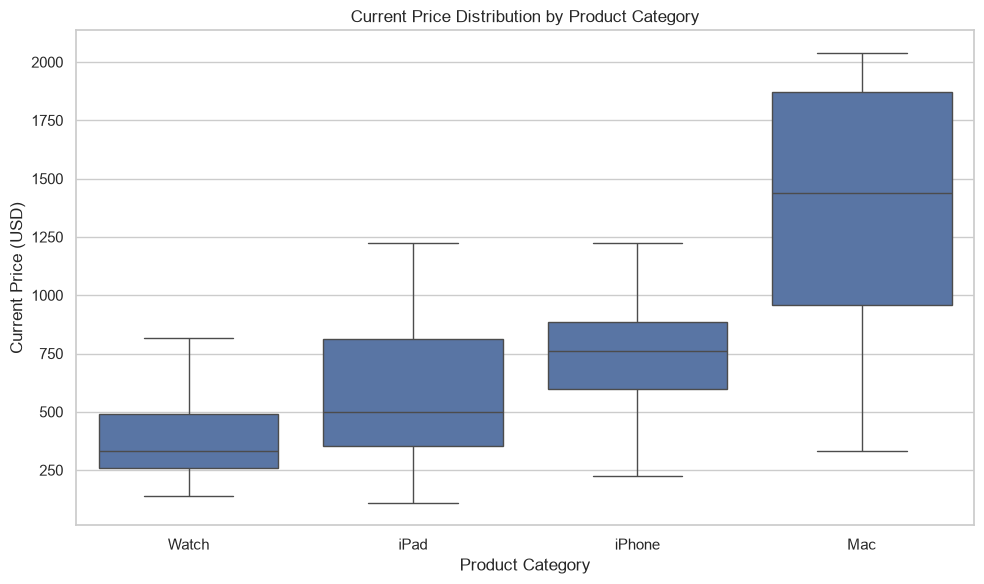

In [157]:
# =============================================================
# 20. CATEGORY PRICE ANALYSIS
# Question 1: Which product categories have the highest prices?
# =============================================================

category_price_summary = (
    df.groupby("product_category")
    .agg(
        records=("current_price_usd", "size"),
        average_price=("current_price_usd", "mean"),
        median_price=("current_price_usd", "median"),
        minimum_price=("current_price_usd", "min"),
        maximum_price=("current_price_usd", "max"),
        average_discount=("discount_pct", "mean"),
        average_price_index=("price_index", "mean"),
    )
    .sort_values(
        "average_price",
        ascending=False,
    )
)

display(category_price_summary)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="product_category",
    y="current_price_usd",
    showfliers=False,
)

plt.title("Current Price Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Current Price (USD)")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "category_price_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

,average_price_index,median_price_index,average_discount,above_msrp_rate
product_category,,,,
Mac,84.57,88.77,15.43,11.07
iPhone,80.43,82.01,19.57,12.91
iPad,73.81,71.38,26.19,8.59
Watch,73.73,75.07,26.27,10.50


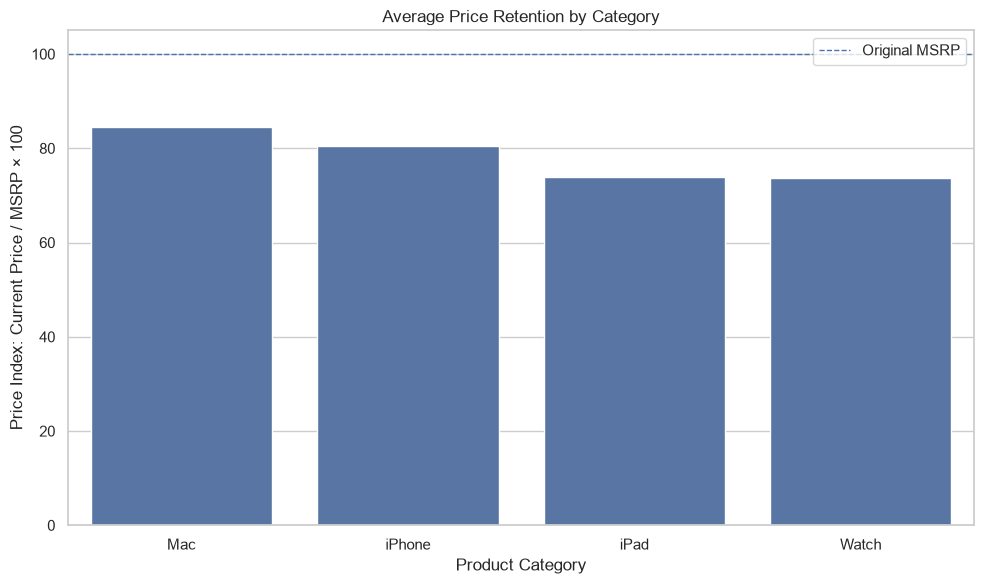

In [158]:
# =====================================================
# 21. VALUE RETENTION BY CATEGORY
# Question 2: Which categories retain their value best?
# ====================================================

value_retention = (
    df.groupby("product_category")
    .agg(
        average_price_index=("price_index", "mean"),
        median_price_index=("price_index", "median"),
        average_discount=("discount_pct", "mean"),
        above_msrp_rate=("is_above_msrp", "mean"),
    )
    .sort_values(
        "average_price_index",
        ascending=False,
    )
)

value_retention["above_msrp_rate"] *= 100

display(value_retention)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=value_retention.reset_index(),
    x="product_category",
    y="average_price_index",
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=1,
    label="Original MSRP",
)

plt.title("Average Price Retention by Category")
plt.xlabel("Product Category")
plt.ylabel("Price Index: Current Price / MSRP × 100")
plt.legend()
plt.tight_layout()

plt.savefig(
    CHART_DIR / "category_value_retention.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

,records,average_price,median_price,average_discount,average_price_index,average_rating
condition,,,,,,
New,59985,830.07,784.56,16.71,83.29,4.55
Renewed/Refurbished,20015,641.02,580.64,35.53,64.47,4.15


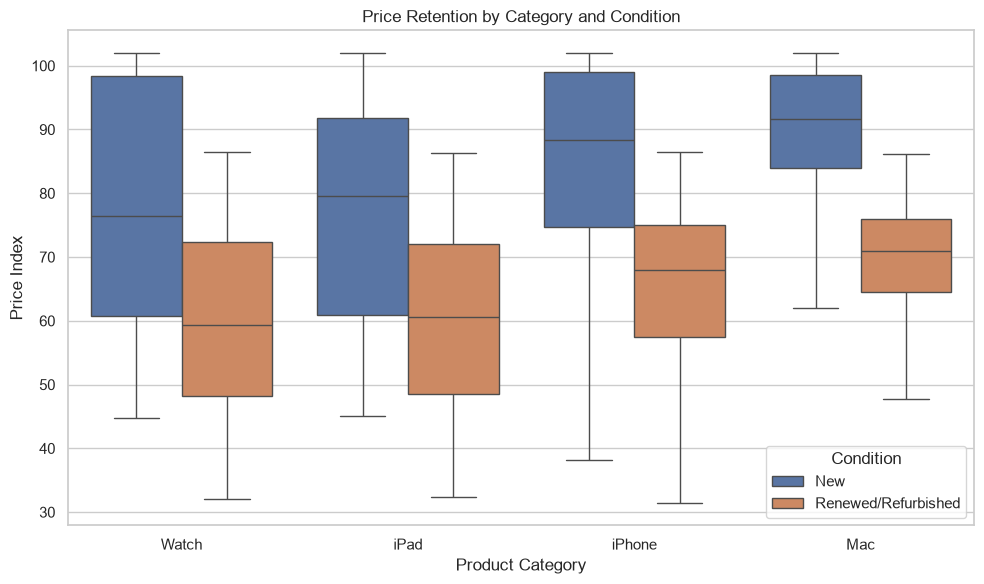

In [159]:
# ============================================
# 22. NEW VS REFURBISHED ANALYSIS
# Question 3: How does condition affect price?
# ============================================

condition_summary = (
    df.groupby("condition")
    .agg(
        records=("current_price_usd", "size"),
        average_price=("current_price_usd", "mean"),
        median_price=("current_price_usd", "median"),
        average_discount=("discount_pct", "mean"),
        average_price_index=("price_index", "mean"),
        average_rating=("rating", "mean"),
    )
    .sort_values(
        "average_price",
        ascending=False,
    )
)

display(condition_summary)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="product_category",
    y="price_index",
    hue="condition",
    showfliers=False,
)

plt.title("Price Retention by Category and Condition")
plt.xlabel("Product Category")
plt.ylabel("Price Index")
plt.legend(title="Condition")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "condition_price_index.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [160]:
# ===========================================
# 23. MATCHED CONDITION COMPARISON
# Statistical test: New vs refurbished prices
# ===========================================

condition_matched = (
    df.groupby(
        [
            "date",
            "platform",
            "model_name",
            "condition",
        ]
    )["price_index"]
    .median()
    .unstack("condition")
)

if {
    "New",
    "Renewed/Refurbished",
}.issubset(condition_matched.columns):

    matched_condition_data = (
        condition_matched[
            [
                "New",
                "Renewed/Refurbished",
            ]
        ]
        .dropna()
    )

    condition_difference = (
        matched_condition_data["New"]
        - matched_condition_data[
            "Renewed/Refurbished"
        ]
    )

    print(
        "Matched comparisons:",
        len(matched_condition_data),
    )

    print(
        "Median price-index difference:",
        condition_difference.median(),
    )

    if len(matched_condition_data) > 0:
        statistic, p_value = wilcoxon(
            matched_condition_data["New"],
            matched_condition_data[
                "Renewed/Refurbished"
            ],
        )

        print("Wilcoxon statistic:", statistic)
        print("P-value:", p_value)

        if p_value < 0.05:
            print(
                "The price difference is statistically significant."
            )
        else:
            print(
                "The price difference is not statistically significant."
            )
else:
    print(
        "The required condition categories were not available."
    )

Matched comparisons: 9168
Median price-index difference: 18.923321901028903
Wilcoxon statistic: 0.0
P-value: 0.0
The price difference is statistically significant.


Platforms available: ['Amazon', 'Flipkart']
Matched product-date-condition comparisons: 12669
Median Amazon minus Flipkart difference: -0.0800000000000125
Amazon cheaper percentage: 50.35125108532639
Flipkart cheaper percentage: 49.609282500591995
Equal price percentage: 0.039466414081616545


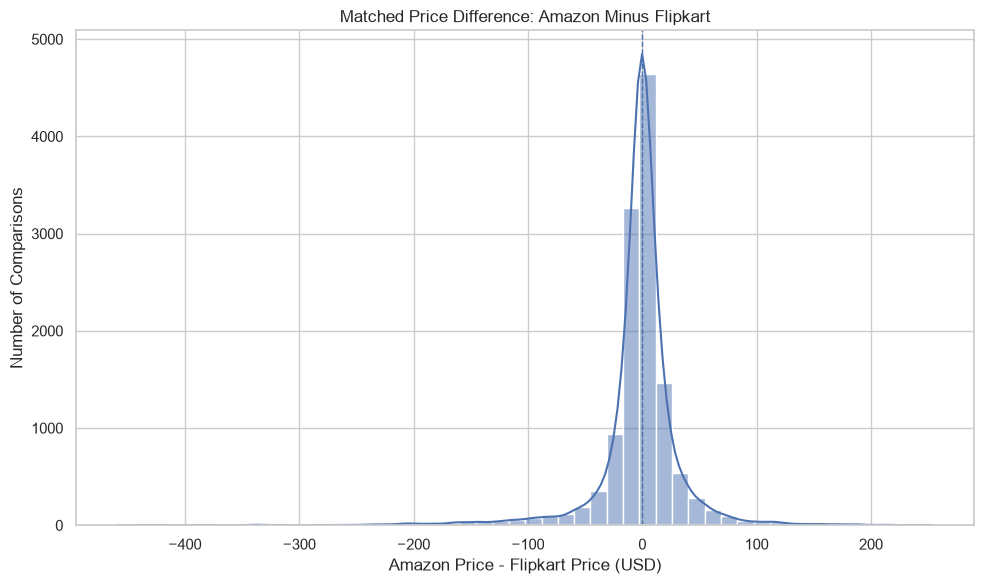

In [161]:
# ======================================
# 24. MATCHED PLATFORM COMPARISON
# Question 4: Which platform is cheaper?
# ======================================

platform_matched = (
    df.groupby(
        [
            "date",
            "model_name",
            "condition",
            "platform",
        ]
    )["current_price_usd"]
    .median()
    .unstack("platform")
)

platforms_available = platform_matched.columns.tolist()

print("Platforms available:", platforms_available)

if {
    "Amazon",
    "Flipkart",
}.issubset(platform_matched.columns):

    paired_platforms = (
        platform_matched[
            [
                "Amazon",
                "Flipkart",
            ]
        ]
        .dropna()
        .copy()
    )

    paired_platforms["amazon_minus_flipkart"] = (
        paired_platforms["Amazon"]
        - paired_platforms["Flipkart"]
    )

    amazon_cheaper_pct = (
        paired_platforms["Amazon"]
        < paired_platforms["Flipkart"]
    ).mean() * 100

    flipkart_cheaper_pct = (
        paired_platforms["Flipkart"]
        < paired_platforms["Amazon"]
    ).mean() * 100

    equal_price_pct = (
        paired_platforms["Amazon"]
        == paired_platforms["Flipkart"]
    ).mean() * 100

    print(
        "Matched product-date-condition comparisons:",
        len(paired_platforms),
    )

    print(
        "Median Amazon minus Flipkart difference:",
        paired_platforms[
            "amazon_minus_flipkart"
        ].median(),
    )

    print(
        "Amazon cheaper percentage:",
        amazon_cheaper_pct,
    )

    print(
        "Flipkart cheaper percentage:",
        flipkart_cheaper_pct,
    )

    print(
        "Equal price percentage:",
        equal_price_pct,
    )

    plt.figure(figsize=(10, 6))

    sns.histplot(
        paired_platforms[
            "amazon_minus_flipkart"
        ],
        bins=50,
        kde=True,
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=1,
    )

    plt.title(
        "Matched Price Difference: Amazon Minus Flipkart"
    )

    plt.xlabel(
        "Amazon Price - Flipkart Price (USD)"
    )

    plt.ylabel("Number of Comparisons")
    plt.tight_layout()

    plt.savefig(
        CHART_DIR / "platform_price_difference.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

else:
    paired_platforms = pd.DataFrame()

    print(
        "Amazon and Flipkart were not both found."
    )

In [162]:
# ==========================================
# 25. PLATFORM SIGNIFICANCE TEST
# Statistical test: Amazon vs Flipkart
# ==========================================

if not paired_platforms.empty:

    non_equal_pairs = paired_platforms.loc[
        paired_platforms["Amazon"]
        != paired_platforms["Flipkart"]
    ]

    if len(non_equal_pairs) > 0:

        statistic, p_value = wilcoxon(
            non_equal_pairs["Amazon"],
            non_equal_pairs["Flipkart"],
        )

        print("Wilcoxon statistic:", statistic)
        print("P-value:", p_value)

        if p_value < 0.05:
            print(
                "There is a statistically significant "
                "matched price difference between platforms."
            )
        else:
            print(
                "There is no statistically significant "
                "matched price difference between platforms."
            )

Wilcoxon statistic: 39608815.5
P-value: 0.23502427902341372
There is no statistically significant matched price difference between platforms.


,records,average_discount,median_discount,average_price,average_price_index,in_stock_rate
sale_event,,,,,,
Big Billion Days,1579,37.02,37.60,596.32,62.98,46.61
Prime Day,1069,34.44,35.20,664.37,65.56,44.90
Great Indian Festival,1504,33.45,33.70,644.10,66.56,71.88
Black Friday,2497,31.46,31.10,685.29,68.54,69.12
None,73351,20.30,19.60,794.67,79.70,69.54


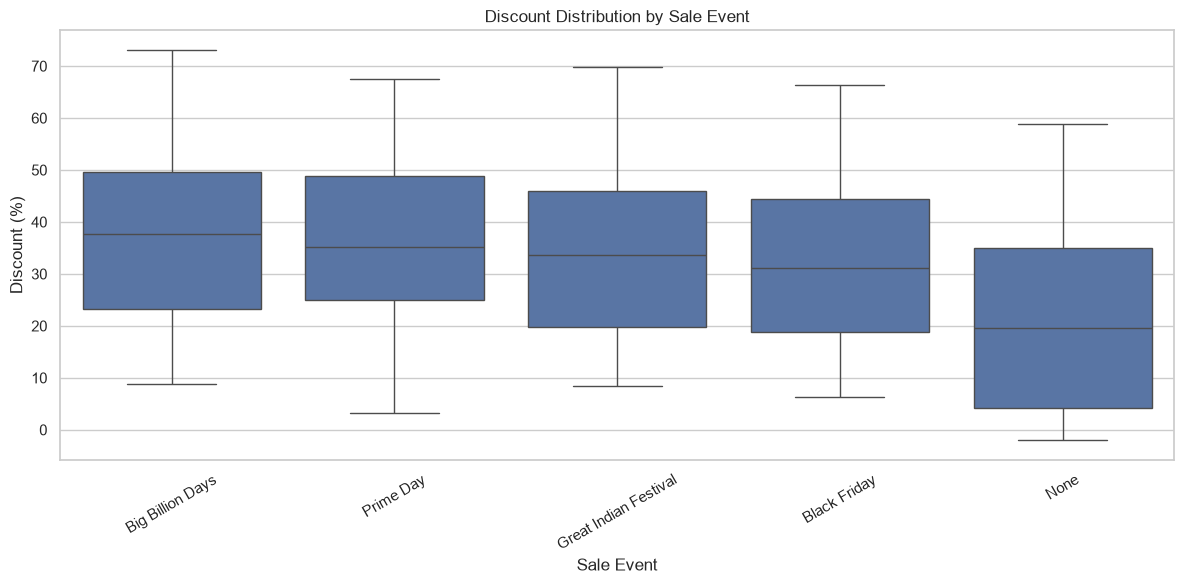

In [163]:
# ============================================================
# 26. SALE-EVENT ANALYSIS
# Question 5: Which sale events provide the largest discounts?
# ============================================================

sale_event_summary = (
    df.groupby("sale_event")
    .agg(
        records=("discount_pct", "size"),
        average_discount=("discount_pct", "mean"),
        median_discount=("discount_pct", "median"),
        average_price=("current_price_usd", "mean"),
        average_price_index=("price_index", "mean"),
        in_stock_rate=("is_in_stock", "mean"),
    )
    .sort_values(
        "average_discount",
        ascending=False,
    )
)

sale_event_summary["in_stock_rate"] *= 100

display(sale_event_summary)

plt.figure(figsize=(12, 6))

event_order = (
    sale_event_summary
    .sort_values(
        "average_discount",
        ascending=False,
    )
    .index
)

sns.boxplot(
    data=df,
    x="sale_event",
    y="discount_pct",
    order=event_order,
    showfliers=False,
)

plt.title("Discount Distribution by Sale Event")
plt.xlabel("Sale Event")
plt.ylabel("Discount (%)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    CHART_DIR / "sale_event_discounts.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [164]:
# ======================================================
# 27. EVENT SAVINGS VS RECENT BASELINE
# Compare event prices with the previous 30 observations
# ======================================================

event_analysis_df = (
    df.groupby(
        [
            "date",
            "platform",
            "model_name",
            "condition",
        ],
        as_index=False,
    )
    .agg(
        current_price_usd=(
            "current_price_usd",
            "median",
        ),
        sale_event=(
            "sale_event",
            lambda values: (
                values.mode().iloc[0]
                if not values.mode().empty
                else values.iloc[0]
            ),
        ),
    )
    .sort_values(
        [
            "platform",
            "model_name",
            "condition",
            "date",
        ]
    )
)

event_group_columns = [
    "platform",
    "model_name",
    "condition",
]

event_analysis_df["previous_30_median"] = (
    event_analysis_df
    .groupby(event_group_columns)[
        "current_price_usd"
    ]
    .transform(
        lambda series:
        series.shift(1)
        .rolling(
            30,
            min_periods=7,
        )
        .median()
    )
)

event_analysis_df[
    "savings_vs_previous_30_pct"
] = (
    (
        event_analysis_df[
            "previous_30_median"
        ]
        - event_analysis_df[
            "current_price_usd"
        ]
    )
    / event_analysis_df[
        "previous_30_median"
    ]
    * 100
)

event_baseline_summary = (
    event_analysis_df
    .dropna(
        subset=[
            "savings_vs_previous_30_pct"
        ]
    )
    .groupby("sale_event")
    .agg(
        observations=(
            "savings_vs_previous_30_pct",
            "size",
        ),
        average_savings_vs_recent_price=(
            "savings_vs_previous_30_pct",
            "mean",
        ),
        median_savings_vs_recent_price=(
            "savings_vs_previous_30_pct",
            "median",
        ),
    )
    .sort_values(
        "average_savings_vs_recent_price",
        ascending=False,
    )
)

display(event_baseline_summary)

,observations,average_savings_vs_recent_price,median_savings_vs_recent_price
sale_event,,,
Big Billion Days,1099,24.60,22.75
Great Indian Festival,1036,20.41,17.62
Prime Day,781,17.49,18.26
Black Friday,1796,14.53,14.13
None,53031,0.42,-0.02


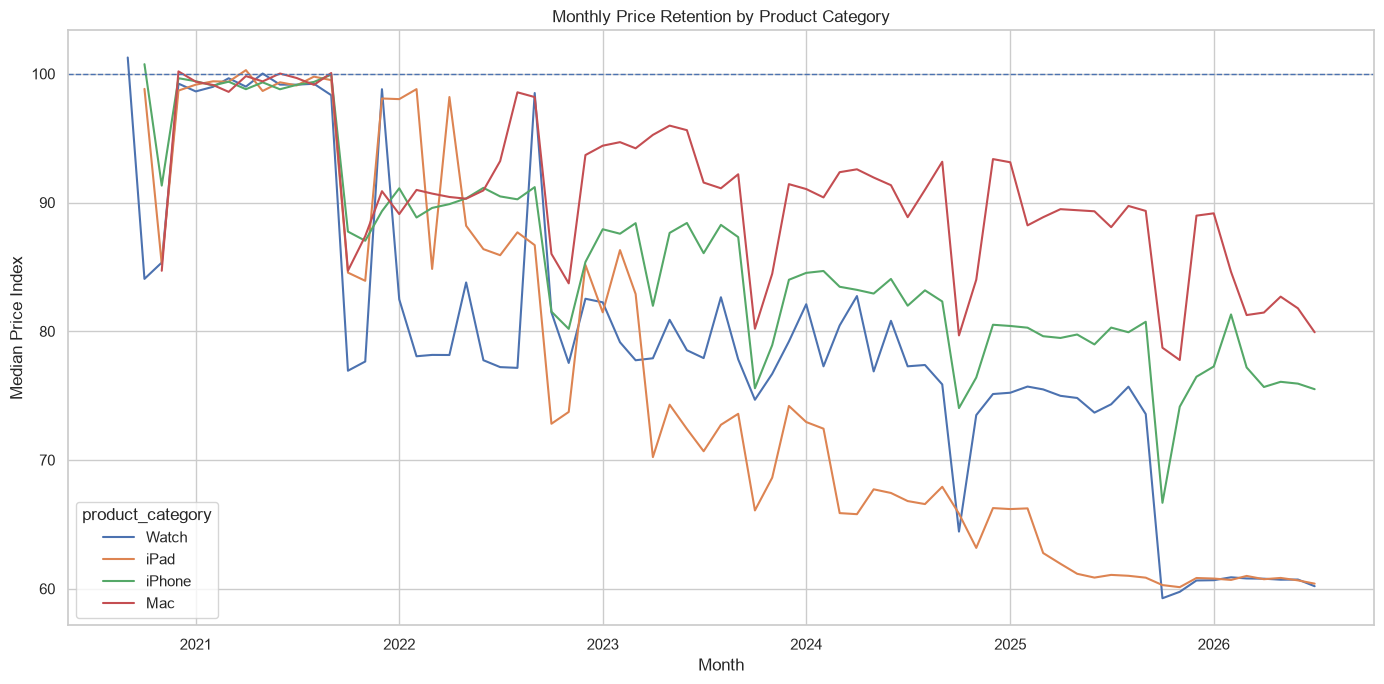

In [165]:
# ===========================================
# 28. MONTHLY PRICE TREND
# Question 6: How do prices change over time?
# ===========================================

monthly_category_prices = (
    df.groupby(
        [
            "year_month",
            "product_category",
        ],
        as_index=False,
    )
    .agg(
        median_price=(
            "current_price_usd",
            "median",
        ),
        median_price_index=(
            "price_index",
            "median",
        ),
        median_discount=(
            "discount_pct",
            "median",
        ),
    )
)

monthly_category_prices["year_month_date"] = (
    pd.to_datetime(
        monthly_category_prices["year_month"]
        + "-01"
    )
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_category_prices,
    x="year_month_date",
    y="median_price_index",
    hue="product_category",
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=1,
)

plt.title("Monthly Price Retention by Product Category")
plt.xlabel("Month")
plt.ylabel("Median Price Index")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "monthly_price_index.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

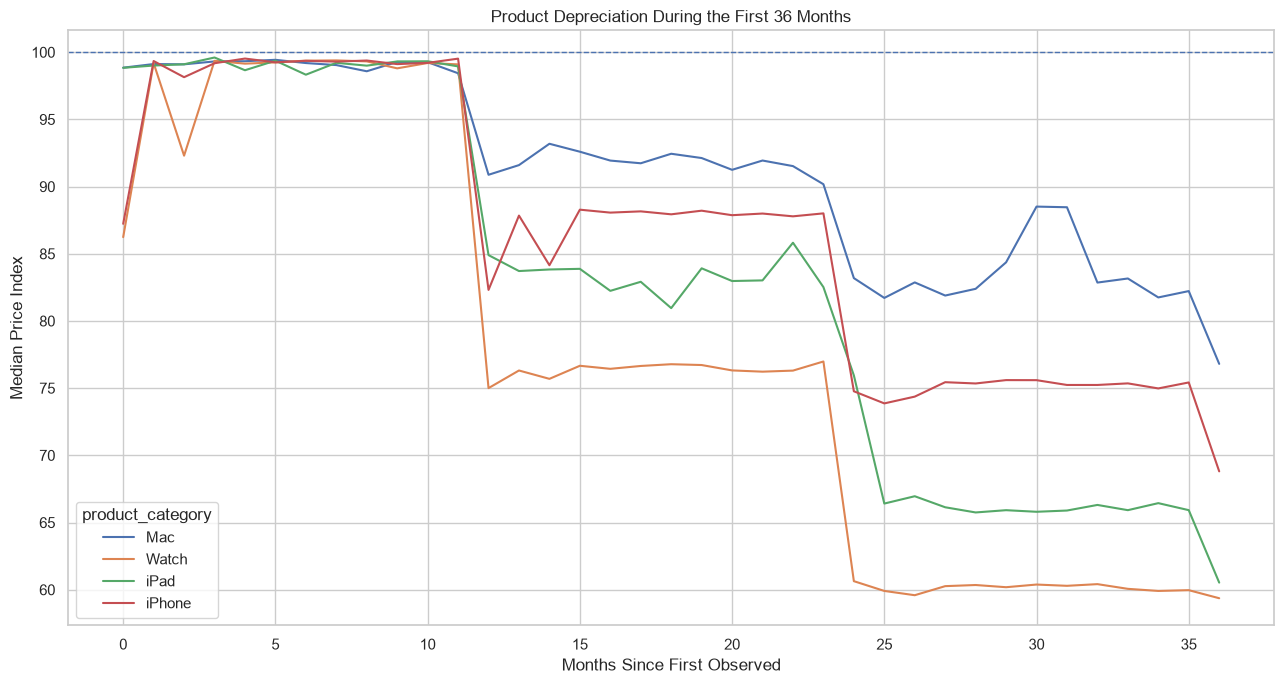

In [166]:
# ===============================================
# 29. PRODUCT DEPRECIATION CURVES
# Question 7: How quickly do products depreciate?
# ===============================================

df["product_age_month"] = (
    df["days_since_first_seen"] // 30
)

depreciation_curve = (
    df.loc[
        df["product_age_month"].between(
            0,
            36,
        )
    ]
    .groupby(
        [
            "product_category",
            "product_age_month",
        ],
        as_index=False,
    )
    .agg(
        median_price_index=(
            "price_index",
            "median",
        ),
        median_discount=(
            "discount_pct",
            "median",
        ),
        records=(
            "current_price_usd",
            "size",
        ),
    )
)

plt.figure(figsize=(13, 7))

sns.lineplot(
    data=depreciation_curve,
    x="product_age_month",
    y="median_price_index",
    hue="product_category",
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=1,
)

plt.title("Product Depreciation During the First 36 Months")
plt.xlabel("Months Since First Observed")
plt.ylabel("Median Price Index")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "category_depreciation_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [167]:
# =================================
# 30. MODEL VALUE-RETENTION RANKING
# =================================

mature_products = df.loc[
    df["days_since_first_seen"] >= 180
].copy()

model_retention = (
    mature_products
    .groupby(
        [
            "product_category",
            "model_name",
        ]
    )
    .agg(
        observations=("price_index", "size"),
        average_price=("current_price_usd", "mean"),
        median_price_index=("price_index", "median"),
        average_discount=("discount_pct", "mean"),
        above_msrp_rate=("is_above_msrp", "mean"),
    )
    .query("observations >= 20")
    .sort_values(
        "median_price_index",
        ascending=False,
    )
)

model_retention["above_msrp_rate"] *= 100

print("Models retaining the most value:")
display(model_retention.head(15))

print("Models with the greatest depreciation:")
display(
    model_retention.sort_values(
        "median_price_index",
        ascending=True,
    ).head(15)
)

Models retaining the most value:


observations  average_price  median_price_index  average_discount  above_msrp_rate
product_category model_name                                                                                                          
iPhone           iPhone 17 128GB                           1162         799.37               99.26              5.85            35.80
Mac              MacBook Pro 14-inch M4 Pro 512GB          1857       1,807.21               94.78              9.59            13.57
                 MacBook Pro 14-inch M3 Pro 512GB          2108       1,758.01               91.03             12.06             7.97
iPhone           iPhone 16 Pro 256GB                       1934         962.92               90.83             12.38            12.98
Mac              MacBook Air M3 256GB                      2077         934.82               89.44             14.94             8.71
                 MacBook Pro 14-inch M2 Pro 512GB          2205       1,723.55               89.34             13.78             5.49
iPad             iPad Pro 11-inch (M4) 256GB               1983         851.71               89.17             14.74             9.73
iPhone           iPhone 16 128GB                           1862         685.94               87.50             14.15            14.72
Mac              MacBook Pro 14-inch M1 Pro 512GB          2297       1,668.34               84.91             16.54             3.61
iPhone           iPhone 15 Pro Max 256GB                   2146       1,005.98               84.46             16.10             7.46
iPad             iPad Pro 12.9-inch (M2) 256GB             2158         966.30               82.40             19.41             5.28
Mac              MacBook Air M2 256GB                      2301         955.04               81.79             20.35             3.91
iPhone           iPhone 14 Pro 128GB                       2379         773.93               79.06             22.53             4.96
Watch            Apple Watch Series X (45mm)               1841         339.37               76.82             20.89            13.85
iPhone           iPhone 15 128GB                           2171         637.71               76.35             20.19             8.89

Models with the greatest depreciation:


,,observations,average_price,median_price_index,average_discount,above_msrp_rate
product_category,model_name,,,,,
Watch,Apple Watch Series 6 (44mm),2351,269.57,59.98,37.16,4.47
iPad,iPad (9th Gen) 64GB,2333,205.64,60.05,37.50,3.86
Watch,Apple Watch Series 7 (45mm),2310,272.47,60.13,36.49,3.81
iPad,iPad Air (4th Gen) 64GB,2422,387.99,60.62,35.23,2.77
Watch,Apple Watch Series 8 (45mm),2271,285.84,60.64,33.37,6.21
iPhone,iPhone 12 64GB,2292,535.63,61.98,32.96,3.84
iPad,iPad Pro 11-inch (M1) 128GB,2396,549.57,63.05,31.22,3.92
iPhone,iPhone 13 128GB,2334,560.09,63.65,29.90,4.88
iPad,iPad Air (5th Gen) 64GB,2319,405.15,65.57,32.36,3.97


In [168]:
# ==========================================
# 31. ABOVE-MSRP ANALYSIS
# Question 8: Which products are most frequently above MSRP?
# ==========================================

above_msrp_summary = (
    df.groupby("model_name")
    .agg(
        observations=("is_above_msrp", "size"),
        above_msrp_rate=("is_above_msrp", "mean"),
        average_premium=("premium_pct", "mean"),
        maximum_premium=("premium_pct", "max"),
    )
    .query("observations >= 20")
    .sort_values(
        "above_msrp_rate",
        ascending=False,
    )
)

above_msrp_summary["above_msrp_rate"] *= 100

display(above_msrp_summary.head(15))

,observations,above_msrp_rate,average_premium,maximum_premium
model_name,,,,
iPhone 17 128GB,2652,34.77,0.35,2.00
MacBook Pro 14-inch M4 Pro 512GB,2623,20.40,0.20,2.00
iPhone 16 128GB,2567,19.63,0.20,2.00
Apple Watch Series X (45mm),2520,18.21,0.18,2.00
iPhone 16 Pro 256GB,2635,17.87,0.19,2.00
iPad Pro 11-inch (M4) 256GB,2575,15.18,0.15,2.00
MacBook Air M3 256GB,2589,14.33,0.15,1.98
iPhone 15 128GB,2602,12.84,0.13,2.00
MacBook Pro 14-inch M3 Pro 512GB,2547,12.45,0.12,2.00


,observations,average_price,median_price,average_price_index,average_discount,average_rating,median_reviews
stock_status,,,,,,,
In Stock,55034,819.92,743.46,81.58,18.42,4.45,"1,599.00"
Low Stock,11491,708.52,603.85,72.72,27.28,4.45,"2,731.00"
Out of Stock,13475,694.37,591.48,71.33,28.67,4.45,"2,956.00"


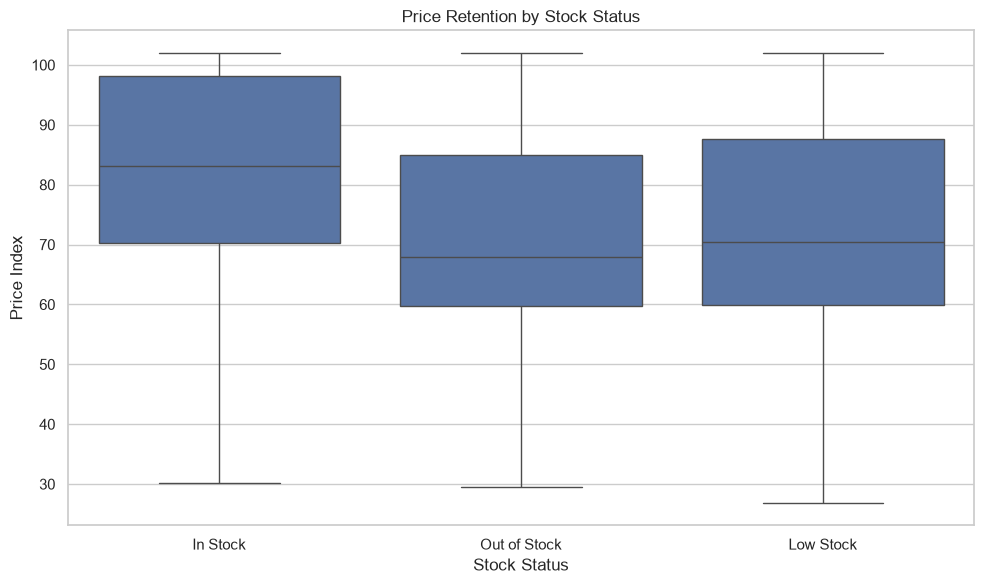

In [169]:
# ===================================================
# 32. STOCK-STATUS ANALYSIS
# Question 9: Does stock availability affect pricing?
# ==================================================

stock_summary = (
    df.groupby("stock_status")
    .agg(
        observations=("current_price_usd", "size"),
        average_price=("current_price_usd", "mean"),
        median_price=("current_price_usd", "median"),
        average_price_index=("price_index", "mean"),
        average_discount=("discount_pct", "mean"),
        average_rating=("rating", "mean"),
        median_reviews=("reviews_count", "median"),
    )
    .sort_values(
        "average_price_index",
        ascending=False,
    )
)

display(stock_summary)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="stock_status",
    y="price_index",
    showfliers=False,
)

plt.title("Price Retention by Stock Status")
plt.xlabel("Stock Status")
plt.ylabel("Price Index")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "stock_status_price_index.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

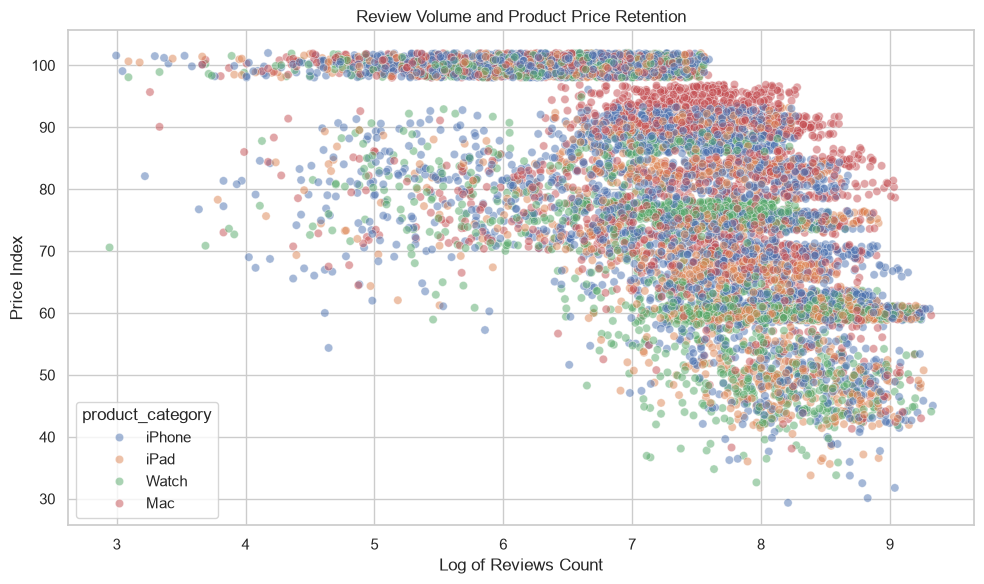

,rating,reviews_count,log_reviews,current_price_usd,discount_pct,price_index,days_since_first_seen
rating,1.00,0.00,0.00,0.11,-0.28,0.28,0.00
reviews_count,0.00,1.00,1.00,-0.32,0.65,-0.65,0.91
log_reviews,0.00,1.00,1.00,-0.32,0.65,-0.65,0.91
current_price_usd,0.11,-0.32,-0.32,1.00,-0.64,0.64,-0.36
discount_pct,-0.28,0.65,0.65,-0.64,1.00,-1.00,0.72
price_index,0.28,-0.65,-0.65,0.64,-1.00,1.00,-0.72
days_since_first_seen,0.00,0.91,0.91,-0.36,0.72,-0.72,1.00


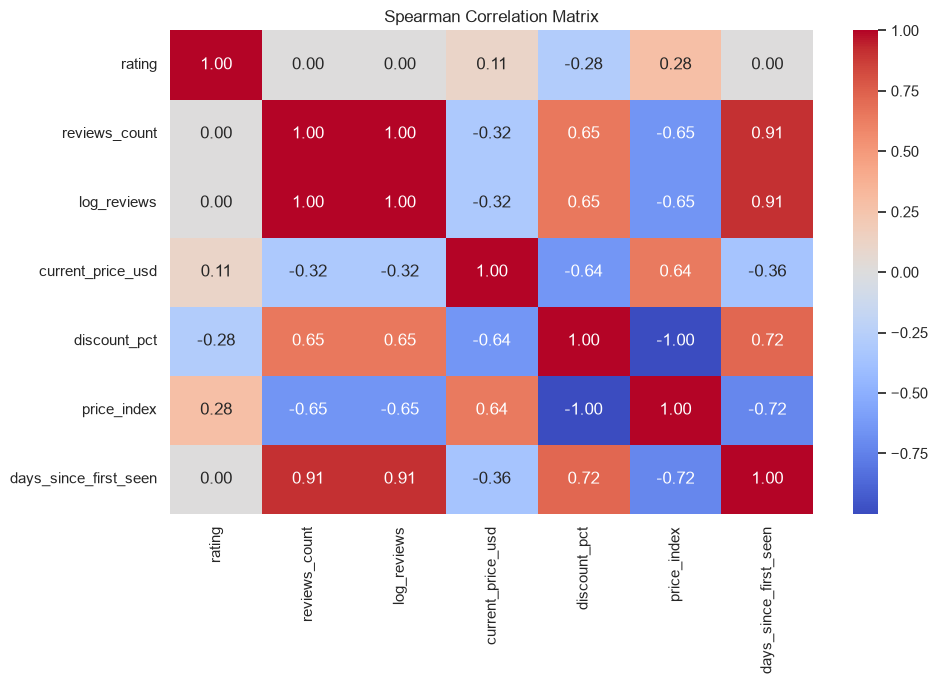

In [170]:
# ======================================================
# 33. RATINGS AND REVIEWS ANALYSIS
# Question 10: Are reviews and ratings related to price?
# ======================================================

sample_size = min(
    10_000,
    len(df),
)

plot_sample = df.sample(
    sample_size,
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_sample,
    x="log_reviews",
    y="price_index",
    hue="product_category",
    alpha=0.5,
)

plt.title("Review Volume and Product Price Retention")
plt.xlabel("Log of Reviews Count")
plt.ylabel("Price Index")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "reviews_vs_price_index.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

review_correlations = (
    df[
        [
            "rating",
            "reviews_count",
            "log_reviews",
            "current_price_usd",
            "discount_pct",
            "price_index",
            "days_since_first_seen",
        ]
    ]
    .corr(method="spearman")
)

display(review_correlations)

plt.figure(figsize=(10, 7))

sns.heatmap(
    review_correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [171]:
# =======================================
# 34. Regression analysis for sale events
# =======================================

regression_df = df[
    [
        "current_price_usd",
        "sale_event",
        "platform",
        "condition",
        "model_name",
        "days_since_first_seen",
        "month",
        "year",
    ]
].dropna().copy()

regression_df["log_price"] = np.log(
    regression_df["current_price_usd"]
)

sale_event_model = smf.ols(
    formula=(
        "log_price ~ "
        "C(sale_event, Treatment(reference='None')) + "
        "C(platform) + "
        "C(condition) + "
        "C(model_name) + "
        "days_since_first_seen + "
        "I(days_since_first_seen ** 2) + "
        "C(month) + "
        "C(year)"
    ),
    data=regression_df,
).fit(
    cov_type="HC3"
)

print(sale_event_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                 7.255e+04
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:13:13   Log-Likelihood:                 99266.
No. Observations:               80000   AIC:                        -1.984e+05
Df Residuals:                   79944   BIC:                        -1.979e+05
Df Model:                          55                                         
Covariance Type:                  HC3                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [172]:
# =================================
# 35. SALE-EVENT REGRESSION RESULTS
# =================================

coefficient_table = pd.DataFrame({
    "coefficient": sale_event_model.params,
    "p_value": sale_event_model.pvalues,
    "lower_95": sale_event_model.conf_int()[0],
    "upper_95": sale_event_model.conf_int()[1],
})

sale_event_coefficients = coefficient_table.loc[
    coefficient_table.index.str.contains(
        "sale_event"
    )
].copy()

sale_event_coefficients[
    "estimated_price_change_pct"
] = (
    np.exp(
        sale_event_coefficients["coefficient"]
    )
    - 1
) * 100

sale_event_coefficients[
    "lower_price_change_pct"
] = (
    np.exp(
        sale_event_coefficients["lower_95"]
    )
    - 1
) * 100

sale_event_coefficients[
    "upper_price_change_pct"
] = (
    np.exp(
        sale_event_coefficients["upper_95"]
    )
    - 1
) * 100

display(
    sale_event_coefficients[
        [
            "estimated_price_change_pct",
            "lower_price_change_pct",
            "upper_price_change_pct",
            "p_value",
        ]
    ]
)

,estimated_price_change_pct,lower_price_change_pct,upper_price_change_pct,p_value
"C(sale_event, Treatment(reference='None'))[T.Big Billion Days]",-21.35,-21.87,-20.81,0.00
"C(sale_event, Treatment(reference='None'))[T.Black Friday]",-13.62,-13.95,-13.30,0.00
"C(sale_event, Treatment(reference='None'))[T.Great Indian Festival]",-17.02,-17.48,-16.56,0.00
"C(sale_event, Treatment(reference='None'))[T.Prime Day]",-17.45,-17.94,-16.95,0.00


In [173]:
# ===============================
# 36. CREATE DAILY MARKET DATASET
# ===============================

def most_common_value(series):
    mode_values = series.mode()

    if not mode_values.empty:
        return mode_values.iloc[0]

    return series.iloc[0]


daily = (
    df.groupby(
        [
            "date",
            "platform",
            "product_category",
            "model_name",
            "condition",
        ],
        as_index=False,
    )
    .agg(
        launch_price_usd=(
            "launch_price_usd",
            "first",
        ),
        minimum_price_usd=(
            "current_price_usd",
            "min",
        ),
        median_price_usd=(
            "current_price_usd",
            "median",
        ),
        maximum_price_usd=(
            "current_price_usd",
            "max",
        ),
        average_price_usd=(
            "current_price_usd",
            "mean",
        ),
        listing_count=(
            "current_price_usd",
            "size",
        ),
        median_rating=(
            "rating",
            "median",
        ),
        median_reviews=(
            "reviews_count",
            "median",
        ),
        in_stock_share=(
            "is_in_stock",
            "mean",
        ),
        low_stock_share=(
            "is_low_stock",
            "mean",
        ),
        out_of_stock_share=(
            "is_out_of_stock",
            "mean",
        ),
        sale_event=(
            "sale_event",
            most_common_value,
        ),
    )
)

daily["price_range_usd"] = (
    daily["maximum_price_usd"]
    - daily["minimum_price_usd"]
)

daily["median_discount_pct"] = (
    (
        daily["launch_price_usd"]
        - daily["median_price_usd"]
    )
    / daily["launch_price_usd"]
    * 100
)

daily["price_index"] = (
    daily["median_price_usd"]
    / daily["launch_price_usd"]
    * 100
)

daily["year"] = daily["date"].dt.year
daily["quarter"] = daily["date"].dt.quarter
daily["month"] = daily["date"].dt.month
daily["week_of_year"] = (
    daily["date"]
    .dt.isocalendar()
    .week
    .astype(int)
)
daily["day_of_week"] = daily["date"].dt.dayofweek
daily["is_weekend"] = (
    daily["day_of_week"] >= 5
).astype(int)

daily_first_seen = (
    daily.groupby("model_name")["date"]
    .transform("min")
)

daily["days_since_first_seen"] = (
    daily["date"]
    - daily_first_seen
).dt.days

daily = daily.sort_values(
    [
        "platform",
        "model_name",
        "condition",
        "date",
    ]
).reset_index(drop=True)

daily.to_csv(
    DAILY_CSV_PATH,
    index=False,
)

print("Daily records:", len(daily))
print("Daily dataset saved to:", DAILY_CSV_PATH)

display(daily.head())

Daily records: 58611
Daily dataset saved to: c:\Users\dbui\Downloads\apple_pricing_project\outputs\daily_market_prices.csv


,date,platform,product_category,model_name,condition,launch_price_usd,minimum_price_usd,median_price_usd,maximum_price_usd,average_price_usd,listing_count,median_rating,median_reviews,in_stock_share,low_stock_share,out_of_stock_share,sale_event,price_range_usd,median_discount_pct,price_index,year,quarter,month,week_of_year,day_of_week,is_weekend,days_since_first_seen
0,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,422.73,423.87,425.00,423.87,2,4.60,110.50,1.00,0.00,0.00,None,2.27,1.20,98.80,2020,3,9,39,2,0,4
1,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,436.22,436.22,436.22,436.22,1,4.70,35.00,1.00,0.00,0.00,None,0.00,-1.68,101.68,2020,3,9,39,3,0,5
2,2020-10-01,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,385.37,387.94,390.51,387.94,2,4.70,95.00,1.00,0.00,0.00,Great Indian Festival,5.14,9.57,90.43,2020,4,10,40,3,0,12
3,2020-10-06,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,348.69,364.57,380.46,364.57,2,4.50,119.50,0.50,0.00,0.50,Great Indian Festival,31.77,15.02,84.98,2020,4,10,41,1,0,17
4,2020-10-11,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,340.08,355.38,370.68,355.38,2,4.65,99.50,1.00,0.00,0.00,Great Indian Festival,30.60,17.16,82.84,2020,4,10,41,6,1,22


In [174]:
# ==============================================
# 37. CREATE FORECAST FEATURES (LAG AND ROLLING)
# ==============================================

forecast_group_columns = [
    "platform",
    "model_name",
    "condition",
]

daily["current_price"] = (
    daily["median_price_usd"]
)

for lag in [
    1,
    7,
    14,
    30,
]:
    daily[f"price_lag_{lag}"] = (
        daily.groupby(
            forecast_group_columns
        )["median_price_usd"]
        .shift(lag)
    )

for window in [
    7,
    14,
    30,
]:
    daily[f"rolling_mean_{window}"] = (
        daily.groupby(
            forecast_group_columns
        )["median_price_usd"]
        .transform(
            lambda series:
            series.shift(1)
            .rolling(
                window,
                min_periods=max(
                    3,
                    window // 3,
                ),
            )
            .mean()
        )
    )

    daily[f"rolling_median_{window}"] = (
        daily.groupby(
            forecast_group_columns
        )["median_price_usd"]
        .transform(
            lambda series:
            series.shift(1)
            .rolling(
                window,
                min_periods=max(
                    3,
                    window // 3,
                ),
            )
            .median()
        )
    )

    daily[f"rolling_std_{window}"] = (
        daily.groupby(
            forecast_group_columns
        )["median_price_usd"]
        .transform(
            lambda series:
            series.shift(1)
            .rolling(
                window,
                min_periods=max(
                    3,
                    window // 3,
                ),
            )
            .std()
        )
    )

daily["price_change_1_observation_pct"] = (
    daily.groupby(
        forecast_group_columns
    )["median_price_usd"]
    .pct_change(1)
    * 100
)

daily["price_change_7_observations_pct"] = (
    daily.groupby(
        forecast_group_columns
    )["median_price_usd"]
    .pct_change(7)
    * 100
)

display(
    daily[
        [
            "date",
            "platform",
            "model_name",
            "median_price_usd",
            "price_lag_1",
            "price_lag_7",
            "rolling_mean_7",
            "rolling_median_30",
        ]
    ].head(20)
)

,date,platform,model_name,median_price_usd,price_lag_1,price_lag_7,rolling_mean_7,rolling_median_30
0,2020-09-23,Amazon,Apple Watch Series 6 (44mm),423.87,NaN,NaN,NaN,NaN
1,2020-09-24,Amazon,Apple Watch Series 6 (44mm),436.22,423.87,NaN,NaN,NaN
2,2020-10-01,Amazon,Apple Watch Series 6 (44mm),387.94,436.22,NaN,NaN,NaN
3,2020-10-06,Amazon,Apple Watch Series 6 (44mm),364.57,387.94,NaN,416.01,NaN
4,2020-10-11,Amazon,Apple Watch Series 6 (44mm),355.38,364.57,NaN,403.15,NaN
5,2020-10-16,Amazon,Apple Watch Series 6 (44mm),429.39,355.38,NaN,393.60,NaN
6,2020-10-22,Amazon,Apple Watch Series 6 (44mm),437.28,429.39,NaN,399.56,NaN
7,2020-10-24,Amazon,Apple Watch Series 6 (44mm),424.81,437.28,423.87,404.95,NaN
8,2020-10-26,Amazon,Apple Watch Series 6 (44mm),433.26,424.81,436.22,405.08,NaN
9,2020-10-28,Amazon,Apple Watch Series 6 (44mm),426.23,433.26,387.94,404.66,NaN


In [175]:
# =====================================================
# 38. CREATE FUTURE FORECAST TARGETS (7-DAY AND 30-DAY)
# =====================================================

def add_future_target(
    data,
    horizon_days,
):
    result = data.copy()

    future_prices = data[
        forecast_group_columns
        + [
            "date",
            "median_price_usd",
        ]
    ].copy()

    future_prices["date"] = (
        future_prices["date"]
        - pd.Timedelta(
            days=horizon_days
        )
    )

    target_name = (
        f"target_price_{horizon_days}d"
    )

    future_prices = future_prices.rename(
        columns={
            "median_price_usd": target_name
        }
    )

    result = result.merge(
        future_prices,
        on=forecast_group_columns
        + ["date"],
        how="left",
    )

    return result


daily = add_future_target(
    daily,
    horizon_days=7,
)

daily = add_future_target(
    daily,
    horizon_days=30,
)

print(
    "Rows with 7-day target:",
    daily["target_price_7d"].notna().sum(),
)

print(
    "Rows with 30-day target:",
    daily["target_price_30d"].notna().sum(),
)

Rows with 7-day target: 25070
Rows with 30-day target: 24449


In [184]:
# ============================
# 39. DEFINE MODELING FEATURES
# ============================

categorical_features = [
    "platform",
    "product_category",
    "model_name",
    "condition",
    "sale_event",
]

numeric_features = [
    "launch_price_usd",
    "median_price_usd",
    "minimum_price_usd",
    "maximum_price_usd",
    "price_range_usd",
    "listing_count",
    "median_rating",
    "median_reviews",
    "in_stock_share",
    "low_stock_share",
    "out_of_stock_share",
    "median_discount_pct",
    "price_index",
    "days_since_first_seen",
    "year",
    "quarter",
    "month",
    "week_of_year",
    "day_of_week",
    "is_weekend",
    "price_lag_1",
    "price_lag_7",
    "price_lag_14",
    "price_lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_median_7",
    "rolling_median_14",
    "rolling_median_30",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_30",
    "price_change_1_observation_pct",
    "price_change_7_observations_pct",
]

model_features = (
    categorical_features
    + numeric_features
)

print("Number of model features:", len(model_features))

Number of model features: 40


In [185]:
# ==============================
# 40. MODEL-EVALUATION FUNCTIONS
# ==============================

def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float).reshape(-1)
    predicted = np.asarray(predicted, dtype=float).reshape(-1)

    if len(actual) != len(predicted):
        raise ValueError(
            f"Length mismatch: actual has {len(actual)} values, "
            f"predicted has {len(predicted)} values."
        )

    # Remove NaN and infinity values
    valid_mask = np.isfinite(actual) & np.isfinite(predicted)

    actual = actual[valid_mask]
    predicted = predicted[valid_mask]

    if len(actual) == 0:
        raise ValueError("No valid values remain for metric calculation.")

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    # Weighted absolute percentage error
    actual_sum = np.abs(actual).sum()

    if actual_sum != 0:
        wape = (
            np.abs(actual - predicted).sum()
            / actual_sum
            * 100
        )
    else:
        wape = np.nan

    # Mean absolute percentage error
    nonzero_mask = actual != 0

    if np.any(nonzero_mask):
        mape = (
            np.mean(
                np.abs(
                    (
                        actual[nonzero_mask]
                        - predicted[nonzero_mask]
                    )
                    / actual[nonzero_mask]
                )
            )
            * 100
        )
    else:
        mape = np.nan

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "WAPE_Percent": float(wape),
        "MAPE_Percent": float(mape),
    }

def print_metrics(
    title,
    metrics,
):
    print(f"\n{title}")

    for metric_name, value in metrics.items():
        print(
            f"{metric_name}: {value:,.4f}"
        )

In [180]:
# ====================================
# 41. FORECAST-MODEL TRAINING FUNCTION
# ====================================

def train_forecast_model(
    data,
    horizon_days,
):
    target_column = (
        f"target_price_{horizon_days}d"
    )

    model_data = data.dropna(
        subset=[
            target_column,
            "price_lag_7",
            "rolling_median_30",
        ]
    ).copy()

    for column in categorical_features:
        model_data[column] = (
            model_data[column]
            .fillna("Unknown")
            .astype(str)
        )

    maximum_date = model_data["date"].max()

    test_start_date = (
        maximum_date
        - pd.Timedelta(days=180)
    )

    validation_start_date = (
        test_start_date
        - pd.Timedelta(days=180)
    )

    train_data = model_data.loc[
        model_data["date"]
        < validation_start_date
    ].copy()

    validation_data = model_data.loc[
        (
            model_data["date"]
            >= validation_start_date
        )
        & (
            model_data["date"]
            < test_start_date
        )
    ].copy()

    test_data = model_data.loc[
        model_data["date"]
        >= test_start_date
    ].copy()

    print(
        f"\n{horizon_days}-day forecast"
    )

    print(
        "Training period:",
        train_data["date"].min(),
        "to",
        train_data["date"].max(),
    )

    print(
        "Validation period:",
        validation_data["date"].min(),
        "to",
        validation_data["date"].max(),
    )

    print(
        "Test period:",
        test_data["date"].min(),
        "to",
        test_data["date"].max(),
    )

    print("Training rows:", len(train_data))
    print("Validation rows:", len(validation_data))
    print("Test rows:", len(test_data))

    X_train = train_data[
        model_features
    ].copy()

    y_train = train_data[
        target_column
    ].copy()

    X_validation = validation_data[
        model_features
    ].copy()

    y_validation = validation_data[
        target_column
    ].copy()

    X_test = test_data[
        model_features
    ].copy()

    y_test = test_data[
        target_column
    ].copy()

    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=1_500,
        learning_rate=0.04,
        depth=8,
        l2_leaf_reg=5,
        random_seed=RANDOM_STATE,
        verbose=100,
        allow_writing_files=False,
    )

    model.fit(
        X_train,
        y_train,
        cat_features=categorical_features,
        eval_set=(
            X_validation,
            y_validation,
        ),
        early_stopping_rounds=100,
        verbose=100,
    )

    predictions = model.predict(
        X_test
    )

    naive_predictions = (
        test_data["median_price_usd"]
        .to_numpy()
    )

    model_metrics = calculate_metrics(
        y_test.to_numpy(),
        predictions,
    )

    naive_metrics = calculate_metrics(
        y_test.to_numpy(),
        naive_predictions,
    )

    print_metrics(
        f"CatBoost {horizon_days}-day forecast",
        model_metrics,
    )

    print_metrics(
        f"Naive current-price baseline",
        naive_metrics,
    )

    improvement_pct = (
        (
            naive_metrics["MAE"]
            - model_metrics["MAE"]
        )
        / naive_metrics["MAE"]
        * 100
    )

    print(
        "\nMAE improvement over baseline:",
        f"{improvement_pct:,.2f}%",
    )

    prediction_results = test_data[
        [
            "date",
            "platform",
            "product_category",
            "model_name",
            "condition",
            "median_price_usd",
            target_column,
        ]
    ].copy()

    prediction_results[
        "predicted_price_usd"
    ] = predictions

    prediction_results[
        "absolute_error"
    ] = np.abs(
        prediction_results[target_column]
        - prediction_results[
            "predicted_price_usd"
        ]
    )

    prediction_results[
        "percentage_error"
    ] = (
        prediction_results[
            "absolute_error"
        ]
        / prediction_results[
            target_column
        ]
        * 100
    )

    feature_importance = pd.DataFrame({
        "feature": model_features,
        "importance": (
            model.get_feature_importance()
        ),
    }).sort_values(
        "importance",
        ascending=False,
    )

    return {
        "model": model,
        "model_data": model_data,
        "train_data": train_data,
        "validation_data": validation_data,
        "test_data": test_data,
        "X_test": X_test,
        "y_test": y_test,
        "predictions": prediction_results,
        "model_metrics": model_metrics,
        "naive_metrics": naive_metrics,
        "improvement_pct": improvement_pct,
        "feature_importance": feature_importance,
    }

In [186]:
# ==============================
# 42. TRAIN 7-DAY FORECAST MODEL
# ==============================

results_7d = train_forecast_model(
    daily,
    horizon_days=7,
)


7-day forecast
Training period: 2020-10-24 00:00:00 to 2025-07-28 00:00:00
Validation period: 2025-07-29 00:00:00 to 2026-01-24 00:00:00
Test period: 2026-01-25 00:00:00 to 2026-07-24 00:00:00
Training rows: 16103
Validation rows: 4151
Test rows: 4331
0:	learn: 343.9709413	test: 356.7646816	best: 356.7646816 (0)	total: 66.7ms	remaining: 1m 39s
100:	learn: 30.4596869	test: 42.9704741	best: 42.9704741 (100)	total: 10.2s	remaining: 2m 21s
200:	learn: 23.4191428	test: 35.1686800	best: 35.1686800 (200)	total: 22.4s	remaining: 2m 24s
300:	learn: 20.1245493	test: 30.7506388	best: 30.7506388 (300)	total: 35.3s	remaining: 2m 20s
400:	learn: 18.1685729	test: 29.0004562	best: 29.0004562 (400)	total: 50s	remaining: 2m 17s
500:	learn: 16.8721599	test: 28.0914357	best: 28.0914357 (500)	total: 1m 4s	remaining: 2m 8s
600:	learn: 15.8996109	test: 27.5853072	best: 27.5853072 (600)	total: 1m 17s	remaining: 1m 56s
700:	learn: 15.1468929	test: 27.4086779	best: 27.4086779 (700)	total: 1m 31s	remaining: 1m 

In [187]:
# ===============================
# 43. TRAIN 30-DAY FORECAST MODEL
# ===============================

results_30d = train_forecast_model(
    daily,
    horizon_days=30,
)


30-day forecast
Training period: 2020-10-23 00:00:00 to 2025-07-05 00:00:00
Validation period: 2025-07-06 00:00:00 to 2026-01-01 00:00:00
Test period: 2026-01-02 00:00:00 to 2026-07-01 00:00:00
Training rows: 15586
Validation rows: 4102
Test rows: 4256
0:	learn: 342.6098384	test: 361.6214783	best: 361.6214783 (0)	total: 83.7ms	remaining: 2m 5s
100:	learn: 31.3845230	test: 45.2483912	best: 45.2483912 (100)	total: 13.7s	remaining: 3m 10s
200:	learn: 23.4554491	test: 35.8050601	best: 35.8050601 (200)	total: 25.9s	remaining: 2m 47s
300:	learn: 19.9477534	test: 29.9780185	best: 29.9780185 (300)	total: 38.6s	remaining: 2m 33s
400:	learn: 17.8641036	test: 26.8921318	best: 26.8921318 (400)	total: 49s	remaining: 2m 14s
500:	learn: 16.6119026	test: 25.6490029	best: 25.6490029 (500)	total: 1m	remaining: 2m
600:	learn: 15.7390715	test: 25.1984546	best: 25.1984546 (600)	total: 1m 10s	remaining: 1m 45s
700:	learn: 15.0368261	test: 24.8039473	best: 24.8039473 (700)	total: 1m 21s	remaining: 1m 32s
80

In [188]:
# ================================================
# 44. COMPARE FORECAST RESULTS (MODEL PERFORMANCE)
# ================================================

model_comparison = pd.DataFrame([
    {
        "forecast_horizon": "7 days",
        "model_mae": results_7d[
            "model_metrics"
        ]["MAE"],
        "baseline_mae": results_7d[
            "naive_metrics"
        ]["MAE"],
        "model_rmse": results_7d[
            "model_metrics"
        ]["RMSE"],
        "model_wape": results_7d[
            "model_metrics"
        ]["WAPE_Percent"],
        "model_r2": results_7d[
            "model_metrics"
        ]["R2"],
        "mae_improvement_pct": results_7d[
            "improvement_pct"
        ],
    },
    {
        "forecast_horizon": "30 days",
        "model_mae": results_30d[
            "model_metrics"
        ]["MAE"],
        "baseline_mae": results_30d[
            "naive_metrics"
        ]["MAE"],
        "model_rmse": results_30d[
            "model_metrics"
        ]["RMSE"],
        "model_wape": results_30d[
            "model_metrics"
        ]["WAPE_Percent"],
        "model_r2": results_30d[
            "model_metrics"
        ]["R2"],
        "mae_improvement_pct": results_30d[
            "improvement_pct"
        ],
    },
])

display(model_comparison)

,forecast_horizon,model_mae,baseline_mae,model_rmse,model_wape,model_r2,mae_improvement_pct
0,7 days,17.97,22.51,34.11,2.28,0.99,20.16
1,30 days,17.50,20.34,34.84,2.24,0.99,13.99


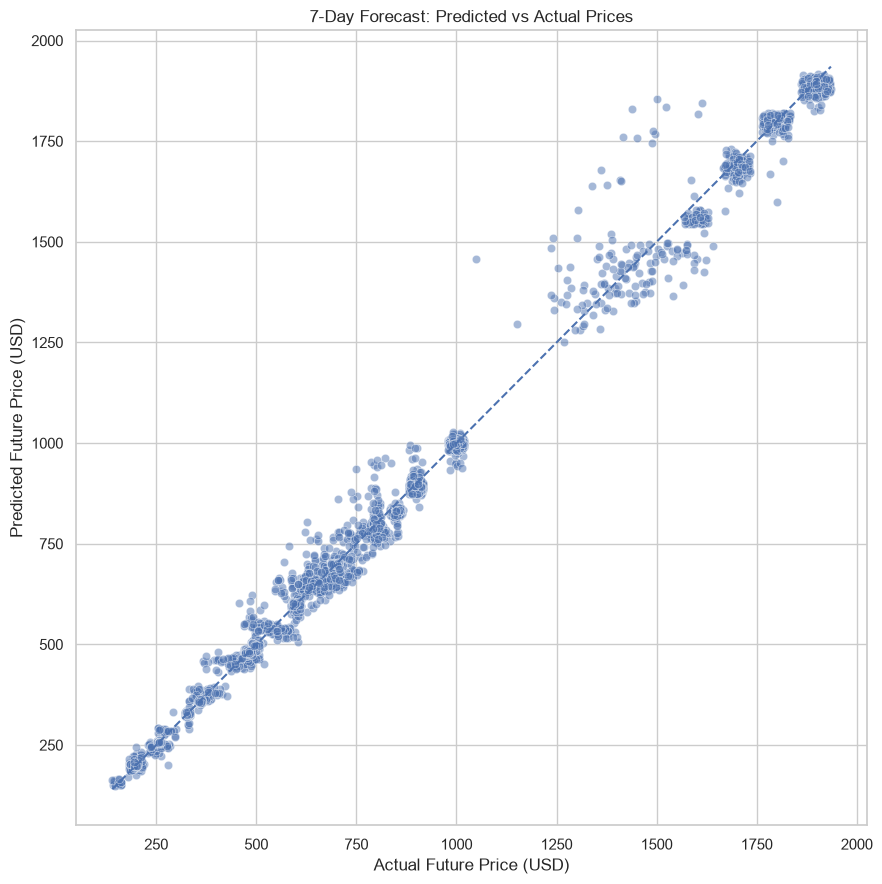

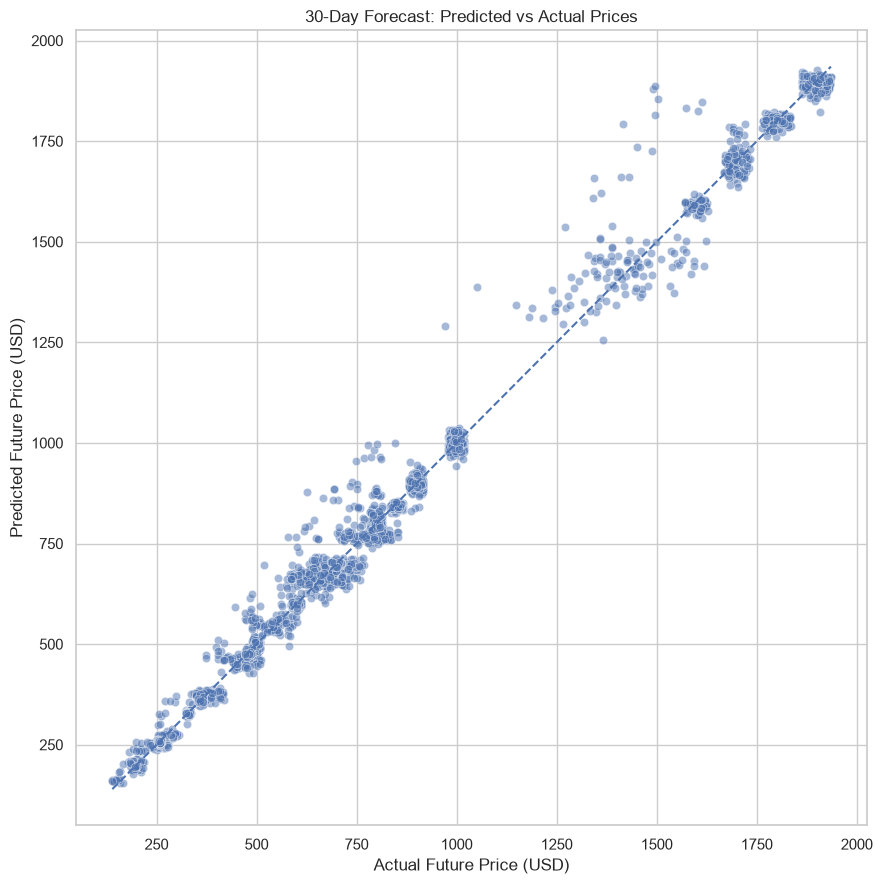

In [189]:
# =====================================
# 45. PREDICTED VS ACTUAL PLOT - PRICES
# =====================================

def plot_predictions(
    results,
    horizon_days,
):
    prediction_data = results[
        "predictions"
    ]

    target_column = (
        f"target_price_{horizon_days}d"
    )

    plt.figure(figsize=(9, 9))

    sns.scatterplot(
        data=prediction_data.sample(
            min(
                5_000,
                len(prediction_data),
            ),
            random_state=RANDOM_STATE,
        ),
        x=target_column,
        y="predicted_price_usd",
        alpha=0.5,
    )

    minimum_value = min(
        prediction_data[target_column].min(),
        prediction_data[
            "predicted_price_usd"
        ].min(),
    )

    maximum_value = max(
        prediction_data[target_column].max(),
        prediction_data[
            "predicted_price_usd"
        ].max(),
    )

    plt.plot(
        [
            minimum_value,
            maximum_value,
        ],
        [
            minimum_value,
            maximum_value,
        ],
        linestyle="--",
    )

    plt.title(
        f"{horizon_days}-Day Forecast: "
        "Predicted vs Actual Prices"
    )

    plt.xlabel("Actual Future Price (USD)")
    plt.ylabel("Predicted Future Price (USD)")
    plt.tight_layout()

    plt.savefig(
        CHART_DIR
        / f"predicted_vs_actual_{horizon_days}d.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


plot_predictions(
    results_7d,
    horizon_days=7,
)

plot_predictions(
    results_30d,
    horizon_days=30,
)

,observations,mae,median_absolute_error,average_percentage_error
product_category,,,,
Mac,1005,32.57,18.74,2.56
iPhone,1808,16.47,10.34,2.42
iPad,604,14.74,6.65,2.56
Watch,914,7.03,3.85,2.16


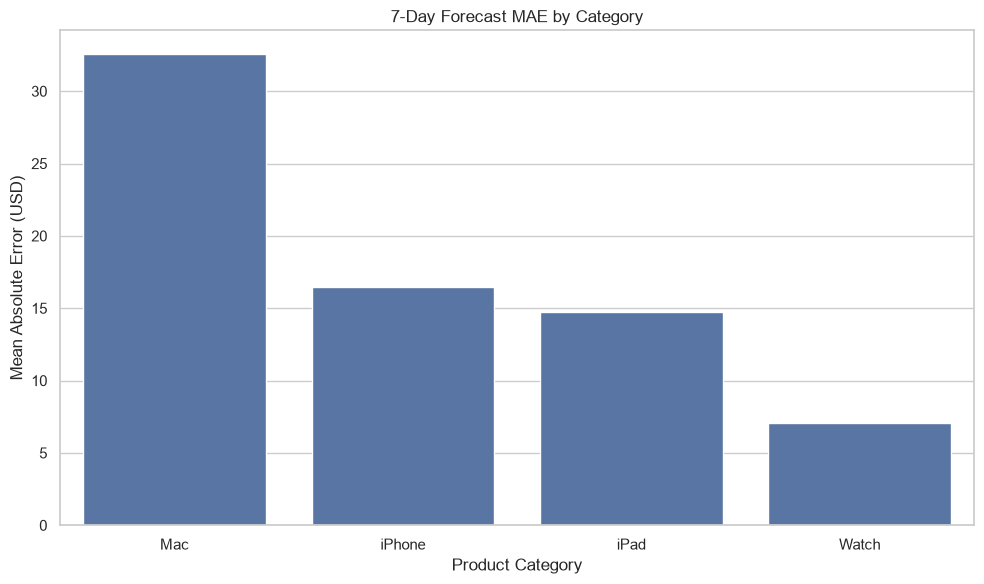

,observations,mae,median_absolute_error,average_percentage_error
product_category,,,,
Mac,970,31.53,17.10,2.60
iPhone,1781,15.87,8.69,2.35
iPad,577,14.48,7.49,2.61
Watch,928,7.85,4.54,2.49


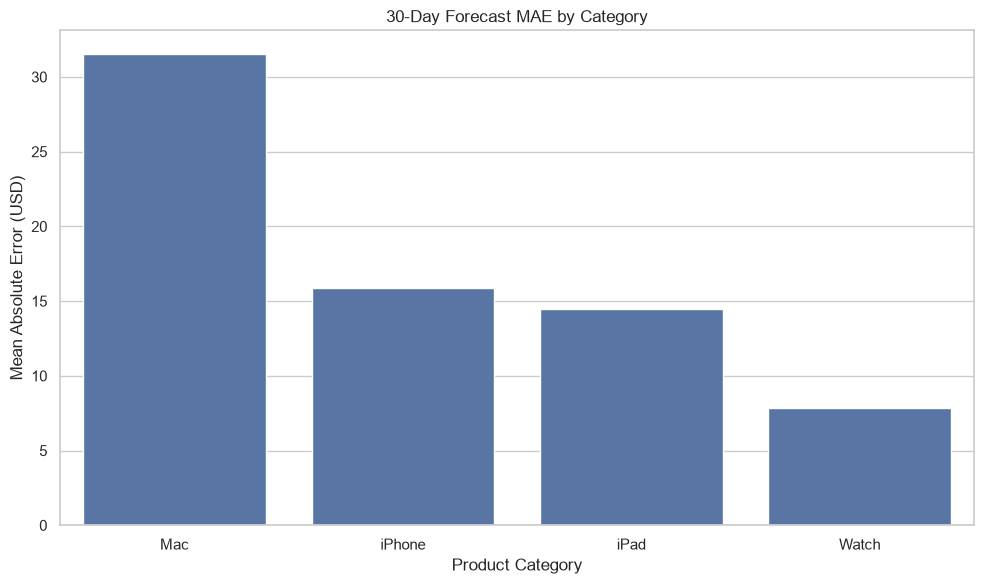

In [190]:
# ==============================
# 46. FORECAST ERROR BY CATEGORY
# ==============================

def error_by_category(
    results,
    horizon_days,
):
    category_errors = (
        results["predictions"]
        .groupby("product_category")
        .agg(
            observations=(
                "absolute_error",
                "size",
            ),
            mae=(
                "absolute_error",
                "mean",
            ),
            median_absolute_error=(
                "absolute_error",
                "median",
            ),
            average_percentage_error=(
                "percentage_error",
                "mean",
            ),
        )
        .sort_values(
            "mae",
            ascending=False,
        )
    )

    display(category_errors)

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=category_errors.reset_index(),
        x="product_category",
        y="mae",
    )

    plt.title(
        f"{horizon_days}-Day Forecast MAE by Category"
    )

    plt.xlabel("Product Category")
    plt.ylabel("Mean Absolute Error (USD)")
    plt.tight_layout()

    plt.savefig(
        CHART_DIR
        / f"forecast_error_category_{horizon_days}d.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return category_errors


category_errors_7d = error_by_category(
    results_7d,
    horizon_days=7,
)

category_errors_30d = error_by_category(
    results_30d,
    horizon_days=30,
)

,feature,importance
8,maximum_price_usd,13.24
7,minimum_price_usd,10.27
35,rolling_std_7,8.92
6,median_price_usd,7.03
31,rolling_mean_30,6.98
5,launch_price_usd,6.73
30,rolling_mean_14,5.22
29,rolling_mean_7,5.09
32,rolling_median_7,4.57
36,rolling_std_14,4.40


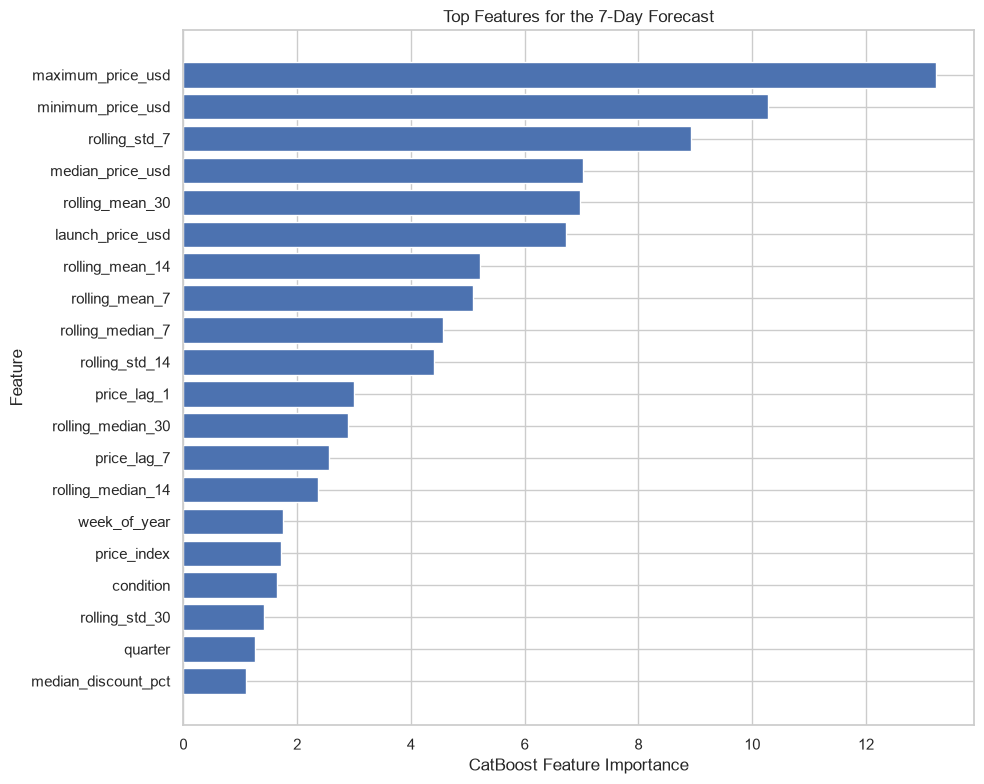

In [191]:
# ======================
# 47. FEATURE IMPORTANCE
# ======================

display(
    results_7d[
        "feature_importance"
    ].head(20)
)

plt.figure(figsize=(10, 8))

top_features = (
    results_7d[
        "feature_importance"
    ]
    .head(20)
    .sort_values(
        "importance",
        ascending=True,
    )
)

plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.title("Top Features for the 7-Day Forecast")
plt.xlabel("CatBoost Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "feature_importance_7d.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

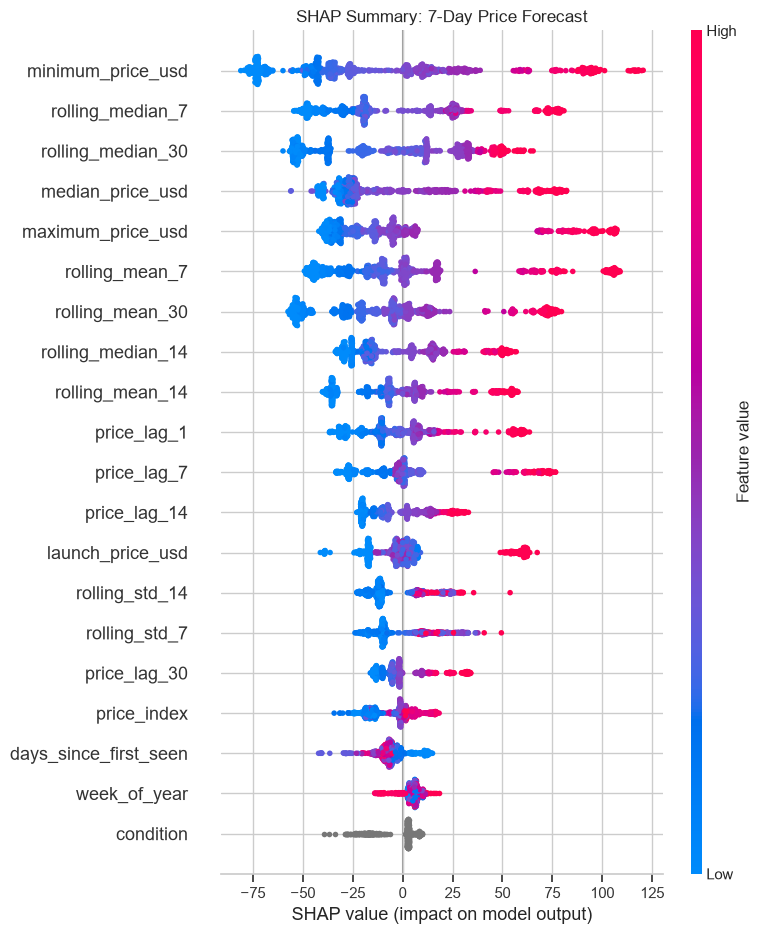

In [192]:
# ======================================================================
# 48. SHAP EXPLANATIONS - explaining how features influenced predictions
# ======================================================================

shap_sample = (
    results_7d["X_test"]
    .sample(
        min(
            1_000,
            len(results_7d["X_test"]),
        ),
        random_state=RANDOM_STATE,
    )
    .copy()
)

shap_pool = Pool(
    shap_sample,
    cat_features=categorical_features,
)

shap_values_with_base = (
    results_7d["model"]
    .get_feature_importance(
        shap_pool,
        type="ShapValues",
    )
)

shap_values = (
    shap_values_with_base[:, :-1]
)

shap.summary_plot(
    shap_values,
    shap_sample,
    show=False,
    max_display=20,
)

plt.title("SHAP Summary: 7-Day Price Forecast")
plt.tight_layout()

plt.savefig(
    CHART_DIR / "shap_summary_7d.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [193]:
# =================================================================================================
# 49. CREATE BUY-NOW DEAL SCORES 
# This ranks products using expected price movement, recent pricing, rating, and stock availability
# ================================================================================================

latest_records = (
    daily.sort_values("date")
    .groupby(
        forecast_group_columns,
        as_index=False,
    )
    .tail(1)
    .copy()
)

for column in categorical_features:
    latest_records[column] = (
        latest_records[column]
        .fillna("Unknown")
        .astype(str)
    )

latest_model_data = latest_records[
    model_features
].copy()

latest_records[
    "predicted_price_7d"
] = (
    results_7d["model"]
    .predict(latest_model_data)
)

latest_records[
    "predicted_change_7d_pct"
] = (
    (
        latest_records[
            "predicted_price_7d"
        ]
        - latest_records[
            "median_price_usd"
        ]
    )
    / latest_records[
        "median_price_usd"
    ]
    * 100
)

latest_records[
    "discount_vs_30_observation_median_pct"
] = (
    (
        latest_records[
            "rolling_median_30"
        ]
        - latest_records[
            "median_price_usd"
        ]
    )
    / latest_records[
        "rolling_median_30"
    ]
    * 100
)

latest_records[
    "future_price_rank"
] = (
    latest_records[
        "predicted_change_7d_pct"
    ]
    .rank(
        pct=True,
    )
)

latest_records[
    "recent_discount_rank"
] = (
    latest_records[
        "discount_vs_30_observation_median_pct"
    ]
    .rank(
        pct=True,
    )
)

latest_records[
    "rating_rank"
] = (
    latest_records[
        "median_rating"
    ]
    .rank(
        pct=True,
    )
)

latest_records[
    "review_rank"
] = (
    latest_records[
        "median_reviews"
    ]
    .rank(
        pct=True,
    )
)

latest_records["deal_score"] = (
    100
    * (
        0.40
        * latest_records[
            "future_price_rank"
        ]
        + 0.30
        * latest_records[
            "recent_discount_rank"
        ]
        + 0.15
        * latest_records[
            "rating_rank"
        ]
        + 0.10
        * latest_records[
            "review_rank"
        ]
        + 0.05
        * latest_records[
            "in_stock_share"
        ]
    )
)

deal_scores = (
    latest_records[
        [
            "date",
            "platform",
            "product_category",
            "model_name",
            "condition",
            "median_price_usd",
            "launch_price_usd",
            "rolling_median_30",
            "predicted_price_7d",
            "predicted_change_7d_pct",
            "discount_vs_30_observation_median_pct",
            "median_rating",
            "median_reviews",
            "in_stock_share",
            "deal_score",
        ]
    ]
    .sort_values(
        "deal_score",
        ascending=False,
    )
)

display(deal_scores.head(20))

,date,platform,product_category,model_name,condition,median_price_usd,launch_price_usd,rolling_median_30,predicted_price_7d,predicted_change_7d_pct,discount_vs_30_observation_median_pct,median_rating,median_reviews,in_stock_share,deal_score
15416,2026-07-20,Amazon,iPad,iPad Air (4th Gen) 64GB,Renewed/Refurbished,267.31,599,276.93,284.32,6.36,3.47,4.00,"9,053.00",1.00,81.73
25426,2026-07-29,Amazon,iPhone,iPhone 14 Pro 128GB,Renewed/Refurbished,489.16,999,555.09,531.89,8.74,11.88,4.20,"5,402.00",0.00,81.55
12450,2026-07-30,Amazon,Mac,MacBook Pro 14-inch M3 Pro 512GB,Renewed/Refurbished,"1,246.09",1999,"1,402.61","1,377.00",10.51,11.16,4.10,"3,183.00",1.00,81.27
30407,2026-07-27,Flipkart,Watch,Apple Watch Series 6 (44mm),Renewed/Refurbished,189.13,429,194.27,200.89,6.22,2.65,4.30,"11,170.00",0.00,80.81
8382,2026-07-30,Amazon,Mac,MacBook Air M2 256GB,New,798.04,1199,892.20,837.31,4.92,10.55,4.50,"3,736.00",0.00,80.42
33339,2026-07-30,Flipkart,Watch,Apple Watch Series 9 (45mm),Renewed/Refurbished,182.22,429,203.94,189.08,3.76,10.65,4.10,"5,528.00",1.00,79.90
47285,2026-07-31,Flipkart,iPad,iPad Pro 11-inch (M4) 256GB,New,787.20,999,801.74,802.33,1.92,1.81,4.90,"2,828.00",1.00,77.96
37810,2026-07-31,Flipkart,Mac,MacBook Air M2 256GB,New,799.53,1199,899.49,834.00,4.31,11.11,4.30,"3,573.00",0.00,76.85
30094,2026-07-31,Flipkart,Watch,Apple Watch Series 6 (44mm),New,252.63,429,258.85,258.04,2.14,2.40,4.60,"5,558.00",0.00,76.83
43237,2026-07-31,Flipkart,iPad,iPad (9th Gen) 64GB,New,193.67,329,198.11,195.98,1.19,2.24,4.70,"7,501.00",0.00,75.91


In [194]:
# ======================
# 50. SAVE MODEL OUTPUTS
# ======================

results_7d["model"].save_model(
    str(
        MODEL_DIR
        / "apple_price_forecast_7d.cbm"
    )
)

results_30d["model"].save_model(
    str(
        MODEL_DIR
        / "apple_price_forecast_30d.cbm"
    )
)

results_7d[
    "predictions"
].to_csv(
    OUTPUT_DIR / "predictions_7d.csv",
    index=False,
)

results_30d[
    "predictions"
].to_csv(
    OUTPUT_DIR / "predictions_30d.csv",
    index=False,
)

deal_scores.to_csv(
    OUTPUT_DIR / "deal_scores.csv",
    index=False,
)

results_7d[
    "feature_importance"
].to_csv(
    OUTPUT_DIR
    / "feature_importance_7d.csv",
    index=False,
)

results_30d[
    "feature_importance"
].to_csv(
    OUTPUT_DIR
    / "feature_importance_30d.csv",
    index=False,
)

model_metrics = {
    "7_day_forecast": {
        "model": results_7d[
            "model_metrics"
        ],
        "baseline": results_7d[
            "naive_metrics"
        ],
        "mae_improvement_pct": float(
            results_7d[
                "improvement_pct"
            ]
        ),
    },
    "30_day_forecast": {
        "model": results_30d[
            "model_metrics"
        ],
        "baseline": results_30d[
            "naive_metrics"
        ],
        "mae_improvement_pct": float(
            results_30d[
                "improvement_pct"
            ]
        ),
    },
}

with open(
    OUTPUT_DIR / "model_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_metrics,
        file,
        indent=4,
    )

print("Models and predictions saved successfully")

Models and predictions saved successfully


In [195]:
# =========================
# 51. GENERATE KEY INSIGHTS
# =========================

key_insights = []

highest_price_category = (
    category_price_summary[
        "average_price"
    ].idxmax()
)

best_retention_category = (
    value_retention[
        "average_price_index"
    ].idxmax()
)

largest_discount_event = (
    sale_event_summary[
        "average_discount"
    ].idxmax()
)

most_above_msrp_model = (
    above_msrp_summary.index[0]
)

key_insights.append(
    f"The category with the highest average "
    f"market price is {highest_price_category}."
)

key_insights.append(
    f"The category retaining the highest percentage "
    f"of its original MSRP is {best_retention_category}."
)

key_insights.append(
    f"The event with the highest average discount "
    f"is {largest_discount_event}."
)

key_insights.append(
    f"The product most frequently trading above MSRP "
    f"is {most_above_msrp_model}."
)

if not paired_platforms.empty:

    if amazon_cheaper_pct > flipkart_cheaper_pct:
        cheaper_platform = "Amazon"
        cheaper_percentage = amazon_cheaper_pct
    else:
        cheaper_platform = "Flipkart"
        cheaper_percentage = flipkart_cheaper_pct

    key_insights.append(
        f"In matched product comparisons, "
        f"{cheaper_platform} was cheaper approximately "
        f"{cheaper_percentage:.1f}% of the time."
    )

key_insights.append(
    f"The seven-day forecast achieved an MAE of "
    f"${results_7d['model_metrics']['MAE']:,.2f}, "
    f"improving over the naive baseline by "
    f"{results_7d['improvement_pct']:.2f}%."
)

key_insights.append(
    f"The 30-day forecast achieved an MAE of "
    f"${results_30d['model_metrics']['MAE']:,.2f}, "
    f"improving over the naive baseline by "
    f"{results_30d['improvement_pct']:.2f}%."
)

for number, insight in enumerate(
    key_insights,
    start=1,
):
    print(f"{number}. {insight}")

with open(
    OUTPUT_DIR / "key_insights.txt",
    "w",
    encoding="utf-8",
) as file:
    for number, insight in enumerate(
        key_insights,
        start=1,
    ):
        file.write(
            f"{number}. {insight}\n"
        )

1. The category with the highest average market price is Mac.
2. The category retaining the highest percentage of its original MSRP is Mac.
3. The event with the highest average discount is Big Billion Days.
4. The product most frequently trading above MSRP is iPhone 17 128GB.
5. In matched product comparisons, Amazon was cheaper approximately 50.4% of the time.
6. The seven-day forecast achieved an MAE of $17.97, improving over the naive baseline by 20.16%.
7. The 30-day forecast achieved an MAE of $17.50, improving over the naive baseline by 13.99%.
